In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Imports and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
categories = pd.read_csv("/content/drive/MyDrive/WUDAC 2025 Datathon/Data/product_categories.csv")
transactions = pd.read_csv("/content/drive/MyDrive/WUDAC 2025 Datathon/Data/transactions.csv")
sessions = pd.read_csv("/content/drive/MyDrive/WUDAC 2025 Datathon/Data/sessions.csv")

# EDA

## Summary Stats and Information

### Exploring Categories Data

NOTE: To link between tables use the "Product Category ID"

In [ ]:
categories.head()

,Product Category ID,Report Category,Item Category,Item Sub-Category
0,999,UNKNOWN,NaN,NaN
1,1000000000,"APPAREL, ACCESSORIES & JEWELRY",NaN,NaN
2,1001000000,"APPAREL, ACCESSORIES & JEWELRY",NaN,NaN
3,1001001000,"APPAREL, ACCESSORIES & JEWELRY",APPAREL,NaN
4,1001001001,"APPAREL, ACCESSORIES & JEWELRY",APPAREL,BABY & MATERNITY CLOTHING


In [ ]:
categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Product Category ID  321 non-null    int64 
 1   Report Category      321 non-null    object
 2   Item Category        293 non-null    object
 3   Item Sub-Category    243 non-null    object
dtypes: int64(1), object(3)
memory usage: 10.2+ KB


321 rows:
- always has a product category id
- always has a report category
- **item category and item sub category can be null**

In [ ]:
categories[categories['Item Category'].isna()]

,Product Category ID,Report Category,Item Category,Item Sub-Category
0,999,UNKNOWN,NaN,NaN
1,1000000000,"APPAREL, ACCESSORIES & JEWELRY",NaN,NaN
2,1001000000,"APPAREL, ACCESSORIES & JEWELRY",NaN,NaN
21,1002000000,"APPAREL, ACCESSORIES & JEWELRY",NaN,NaN
33,2000000000,"BOOKS, MUSIC & VIDEO",NaN,NaN
34,2003000000,"BOOKS, MUSIC & VIDEO",NaN,NaN
57,3000000000,ELECTRONICS & COMPUTING,NaN,NaN
58,3004000000,ELECTRONICS & COMPUTING,NaN,NaN
89,4000000000,OFFICE SUPPLIES & BUSINESS MACHINES,NaN,NaN
90,4005000000,OFFICE SUPPLIES & BUSINESS MACHINES,NaN,NaN


In [ ]:
categories['Item Category'] = categories['Item Category'].fillna("UNKNOWN")
categories['Item Sub-Category'] = categories['Item Category'].fillna("UNKNOWN")

In [ ]:
categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Product Category ID  321 non-null    int64 
 1   Report Category      321 non-null    object
 2   Item Category        321 non-null    object
 3   Item Sub-Category    321 non-null    object
dtypes: int64(1), object(3)
memory usage: 10.2+ KB


In [ ]:
ebay = transactions[transactions['domain_name'] == 'ebay.com']
merged_ebay = pd.merge(ebay, categories, left_on ='prod_category_id', right_on = 'Product Category ID')

print(len(merged_ebay['Report Category'].value_counts()))
print(len(merged_ebay['Item Category'].value_counts()))

10
37


In [ ]:
len(categories['Report Category'].value_counts())

12

In [ ]:
len(categories['Item Category'].value_counts())

50

In [ ]:
categories['Item Sub-Category'].value_counts()

,count
Item Sub-Category,
UNKNOWN,28
FOOD & BEVERAGE,22
HOME IMPROVEMENT,21
BOOKS,18
APPAREL,16
TOYS,15
BABY,14
AUTO & TIRES,13
BEAUTY,11


#### Key Notes
- most common known item category = FOOD & BEVERAGE
- most common known item sub-category = FOOD & BEVERAGE
- most common report category = HOME & LIVING (High-level category of purchased product)

### Exploring Transactions Data

In [ ]:
transactions.head()

,machine_id,site_session_id,prod_category_id,prod_name,domain_id,prod_qty,prod_totprice,basket_tot,event_date,event_time,domain_name,total_transactions_2020,total_transactions_2021,total_transactions_2022,total_transactions_2023
0,285811167,7837313750729559995,1001001014,SaiLiiny Vest for Boys 3 Buttons Slim Fit Dres...,4.046670e+18,1.0,15.66,593.07,2020-01-01,0:01:03,amazon.com,69.0,NaN,NaN,NaN
1,285811167,7837313750729559995,1002004139,Mr and Mrs Cake Topper Rhinestone Crystal Meta...,4.046670e+18,1.0,17.99,593.07,2020-01-01,0:01:03,amazon.com,69.0,NaN,NaN,NaN
2,285811167,7837313750729559995,4005017229,"Hoffmaster 114000 Plastic Tablecover Roll, 300...",4.046670e+18,2.0,38.24,593.07,2020-01-01,0:01:03,amazon.com,69.0,NaN,NaN,NaN
3,285811167,7837313750729559995,1002004139,"HiiARug Handmade Wedding Bouquets, Artificial ...",4.046670e+18,1.0,35.98,593.07,2020-01-01,0:01:03,amazon.com,69.0,NaN,NaN,NaN
4,285811167,7837313750729559995,1001001014,CHAMA Men's Formal Classic Fit Business Dress ...,4.046670e+18,1.0,24.69,593.07,2020-01-01,0:01:03,amazon.com,69.0,NaN,NaN,NaN


In [ ]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2308972 entries, 0 to 2308971
Data columns (total 15 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   machine_id               int64  
 1   site_session_id          int64  
 2   prod_category_id         int64  
 3   prod_name                object 
 4   domain_id                float64
 5   prod_qty                 float64
 6   prod_totprice            float64
 7   basket_tot               float64
 8   event_date               object 
 9   event_time               object 
 10  domain_name              object 
 11  total_transactions_2020  float64
 12  total_transactions_2021  float64
 13  total_transactions_2022  float64
 14  total_transactions_2023  float64
dtypes: float64(8), int64(3), object(4)
memory usage: 264.2+ MB


### Exploring Sessions Data




*   IDEA = can be very good to see where people churn -- make a plot for that
*   break it down as a funnel plot and see where certain demographics phase out
*   logistic regression for predicting purchase or not? -- does category, zip code, etc affect it?

merge with transactions on site_session_id


In [ ]:
sessions.head()

,machine_id,site_session_id,user_session_id,domain_id,ref_domain__name,pages_viewed,duration,event_date,event_time,hoh_most_education,census_region,household_size,hoh_oldest_age,household_income,children,racial_background,connection_speed,hispanic,zip_code,domain_name
0,288084937,6729633401426801739,2412880849370001,1.058424e+19,NaN,14.0,14.0,2020-01-01,0:00:02,4.0,3.0,2.0,11.0,16.0,0.0,1.0,NaN,0.0,28428.0,ebay.com
1,288912140,1092751701181111355,2412889121400001,1.058424e+19,NaN,34.0,31.0,2020-01-01,0:00:02,99.0,1.0,3.0,11.0,16.0,1.0,1.0,1.0,0.0,13326.0,ebay.com
2,285811167,7837313750729559995,2412858111670001,4.046670e+18,NaN,4.0,3.0,2020-01-01,0:00:02,2.0,3.0,5.0,5.0,13.0,1.0,1.0,1.0,0.0,77488.0,amazon.com
3,290119393,192904185306363414,2412901193930001,4.046670e+18,amazon.com,15.0,9.0,2020-01-01,0:00:02,4.0,3.0,5.0,7.0,18.0,1.0,5.0,1.0,1.0,NaN,amazon.com
4,306223388,6798383743536217771,2413062233880001,4.046670e+18,NaN,23.0,53.0,2020-01-01,0:00:02,3.0,2.0,2.0,6.0,11.0,0.0,1.0,1.0,0.0,55337.0,amazon.com


In [ ]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13765666 entries, 0 to 13765665
Data columns (total 20 columns):
 #   Column              Dtype  
---  ------              -----  
 0   machine_id          int64  
 1   site_session_id     int64  
 2   user_session_id     int64  
 3   domain_id           float64
 4   ref_domain__name    object 
 5   pages_viewed        float64
 6   duration            float64
 7   event_date          object 
 8   event_time          object 
 9   hoh_most_education  float64
 10  census_region       float64
 11  household_size      float64
 12  hoh_oldest_age      float64
 13  household_income    float64
 14  children            float64
 15  racial_background   float64
 16  connection_speed    float64
 17  hispanic            float64
 18  zip_code            float64
 19  domain_name         object 
dtypes: float64(13), int64(3), object(4)
memory usage: 2.1+ GB


In [ ]:
sessions['domain_name'].unique()

array(['ebay.com', 'amazon.com', 'walmart.com', 'target.com', 'etsy.com'],
      dtype=object)

In [ ]:
(sessions['household_size'].unique())
# -88 and 99 means unknown

array([  2.,   3.,   5.,   4.,  nan,   1.,  99., -88.])

In [ ]:
(sessions['census_region'].unique())
# 99 means unkown

array([ 3.,  1.,  2.,  4., nan, 99.])

In [ ]:
sessions['racial_background'].unique()

array([ 1.,  5.,  3.,  2., nan, 99.])

# Plotting Customer Behavior (Overall)

<ipython-input-23-d25f18cb92dd>:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_totals = transactions.groupby('month')['basket_tot'].sum().reset_index()


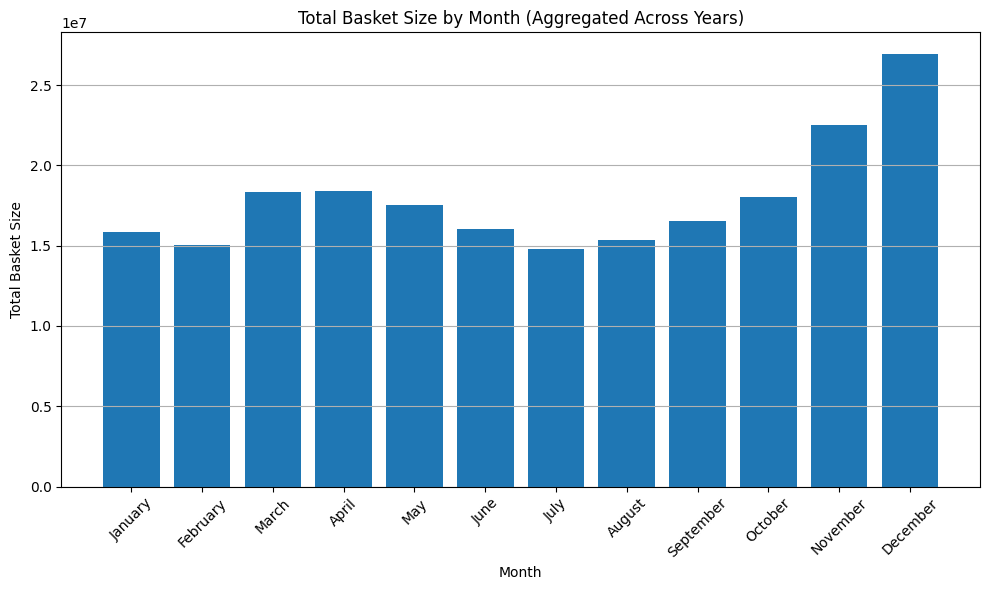

In [ ]:
import matplotlib.pyplot as plt

# Convert event_date to datetime and extract just the month name
transactions['event_date'] = pd.to_datetime(transactions['event_date'])
transactions['month'] = transactions['event_date'].dt.month_name()

# Optional: to maintain consistent month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
transactions['month'] = pd.Categorical(transactions['month'], categories=month_order, ordered=True)

# Group by month and sum basket_tot
monthly_totals = transactions.groupby('month')['basket_tot'].sum().reset_index()

# Bar plot
plt.figure(figsize=(10, 6))
plt.bar(monthly_totals['month'], monthly_totals['basket_tot'])
plt.title('Total Basket Size by Month (Aggregated Across Years)')
plt.xlabel('Month')
plt.ylabel('Total Basket Size')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()


<ipython-input-24-279ea0c9ef96>:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_qty = transactions.groupby(['site_session_id', 'month'])['prod_qty'].sum().reset_index()
<ipython-input-24-279ea0c9ef96>:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_qty_per_cart = session_qty.groupby('month')['prod_qty'].mean().reset_index()


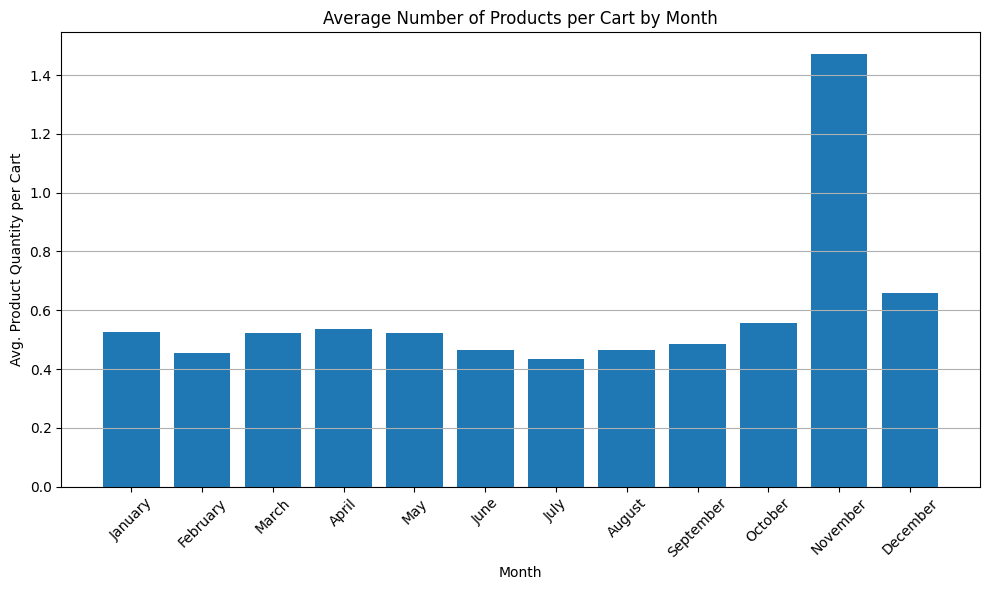

In [ ]:
import matplotlib.pyplot as plt

# Convert event_date to datetime and extract just the month name
transactions['event_date'] = pd.to_datetime(transactions['event_date'])
transactions['month'] = transactions['event_date'].dt.month_name()

# Maintain consistent month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
transactions['month'] = pd.Categorical(transactions['month'], categories=month_order, ordered=True)

# First, get total product quantity per session
session_qty = transactions.groupby(['site_session_id', 'month'])['prod_qty'].sum().reset_index()

# Then, compute the average prod_qty per cart by month
avg_qty_per_cart = session_qty.groupby('month')['prod_qty'].mean().reset_index()

# Bar plot
plt.figure(figsize=(10, 6))
plt.bar(avg_qty_per_cart['month'], avg_qty_per_cart['prod_qty'])
plt.title('Average Number of Products per Cart by Month')
plt.xlabel('Month')
plt.ylabel('Avg. Product Quantity per Cart')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()


<ipython-input-25-a4b246e719fd>:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_price = transactions.groupby(['site_session_id', 'month'])['prod_totprice'].sum().reset_index()
<ipython-input-25-a4b246e719fd>:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_per_cart = session_price.groupby('month')['prod_totprice'].mean().reset_index()


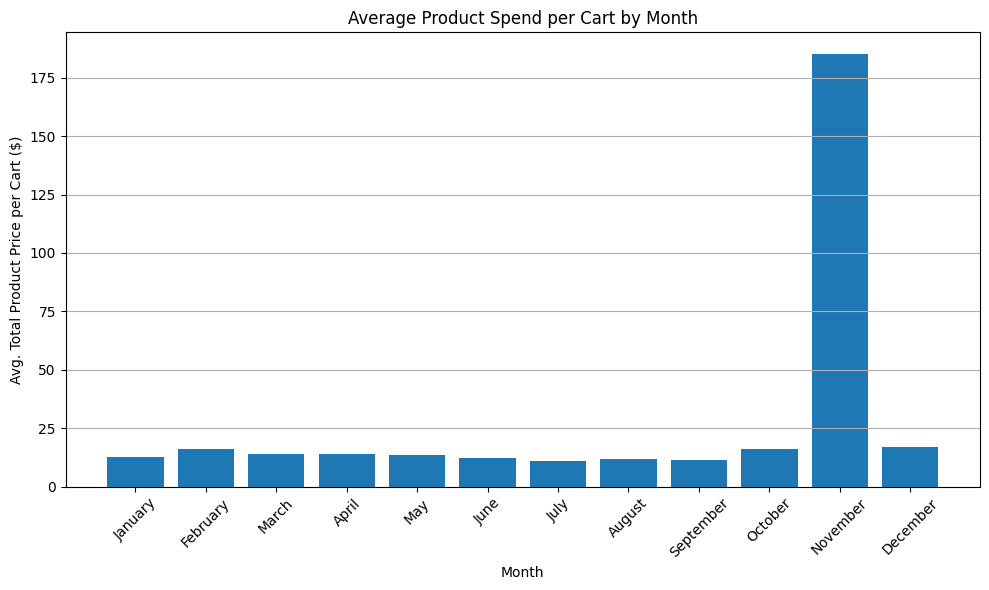

In [ ]:
import matplotlib.pyplot as plt

# Convert event_date to datetime and extract just the month name
transactions['event_date'] = pd.to_datetime(transactions['event_date'])
transactions['month'] = transactions['event_date'].dt.month_name()

# Maintain consistent month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
transactions['month'] = pd.Categorical(transactions['month'], categories=month_order, ordered=True)

# First, get total product price per session
session_price = transactions.groupby(['site_session_id', 'month'])['prod_totprice'].sum().reset_index()

# Then, compute the average product price per cart by month
avg_price_per_cart = session_price.groupby('month')['prod_totprice'].mean().reset_index()

# Bar plot
plt.figure(figsize=(10, 6))
plt.bar(avg_price_per_cart['month'], avg_price_per_cart['prod_totprice'])
plt.title('Average Product Spend per Cart by Month')
plt.xlabel('Month')
plt.ylabel('Avg. Total Product Price per Cart ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

## Establishing Segments for Data

user activity -- group by these different things and see how long the duraiton is for each

demographics
- hoh stats
- connection speed
- income
- zip code
- census

### Segments by Store

In [ ]:
ebay = sessions[sessions['domain_name'] == 'ebay.com']
amazon = sessions[sessions['domain_name'] == 'amazon.com']
walmart = sessions[sessions['domain_name'] == 'walmart.com']
target = sessions[sessions['domain_name'] == 'target.com']
etsy = sessions[sessions['domain_name'] == 'etsy.com']

### Segments by Household Size
can become more granular with children later, hoh oldest age, household_income (can group to high middle low)

In [ ]:
house_1 = sessions[sessions['household_size'] == '1']
house_2 = sessions[sessions['household_size'] == '2']
house_3 = sessions[sessions['household_size'] == '3']
house_4 = sessions[sessions['household_size'] == '4']
house_5 = sessions[sessions['household_size'] == '5']

### Segments by Census Region

can become more granular later w/ zipcode size -- potential for supplemental data from census and zip code

In [ ]:
census_1 = sessions[sessions['census_region'] == '1']
census_2 = sessions[sessions['census_region'] == '2']
census_3 = sessions[sessions['census_region'] == '3']
census_4 = sessions[sessions['census_region'] == '4']

### Segments by Demographic Type

In [ ]:
race_1 = sessions[sessions['racial_background'] == '1']
race_2 = sessions[sessions['racial_background'] == '2']
race_3 = sessions[sessions['racial_background'] == '3']
race_5 = sessions[sessions['racial_background'] == '5']

## Data Distributions

# Customer Behavior by Store

<ipython-input-30-4ba3ea0a31bb>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-30-4ba3ea0a31bb>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


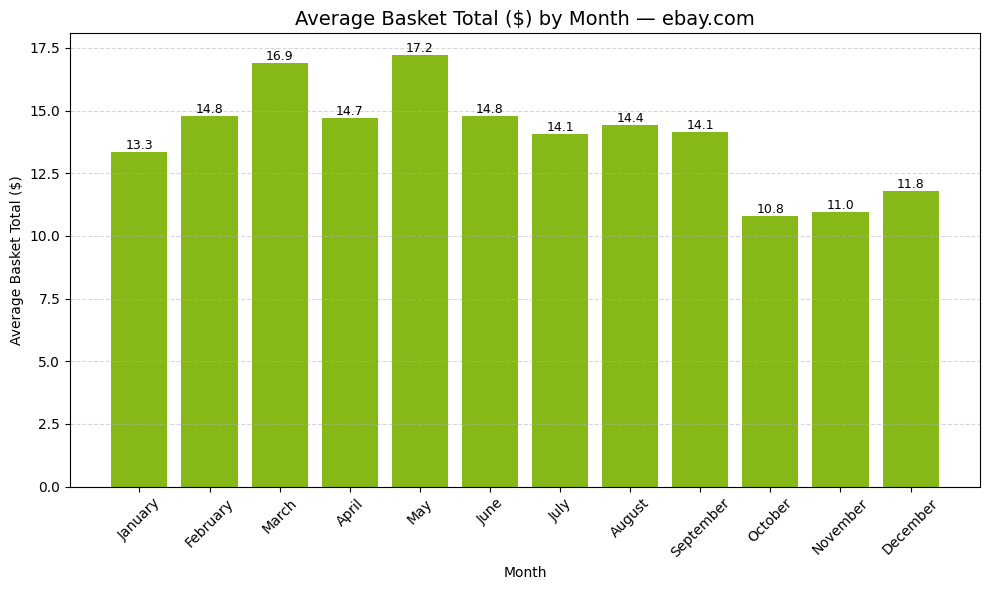

<ipython-input-30-4ba3ea0a31bb>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-30-4ba3ea0a31bb>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


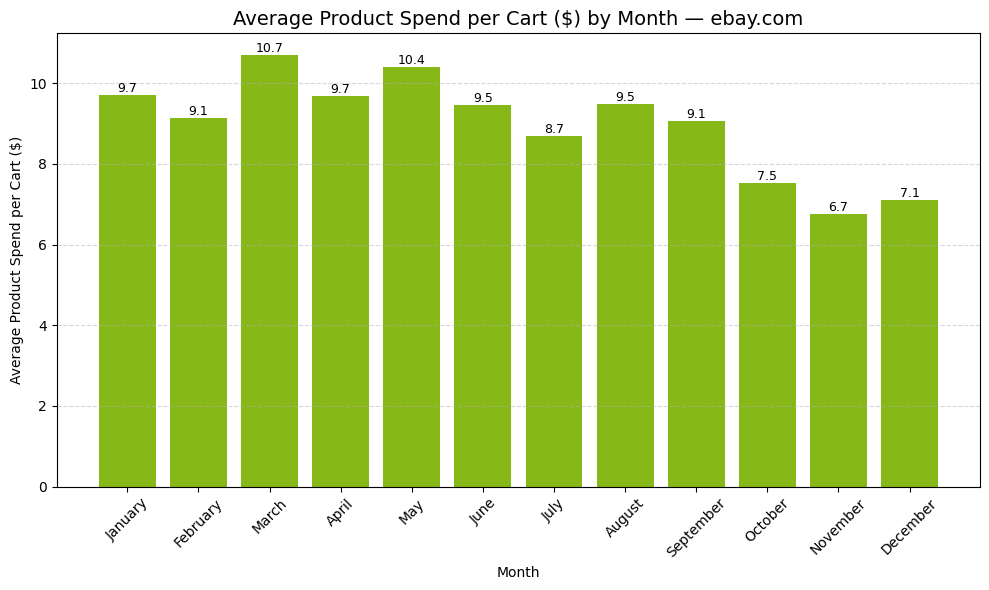

<ipython-input-30-4ba3ea0a31bb>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-30-4ba3ea0a31bb>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


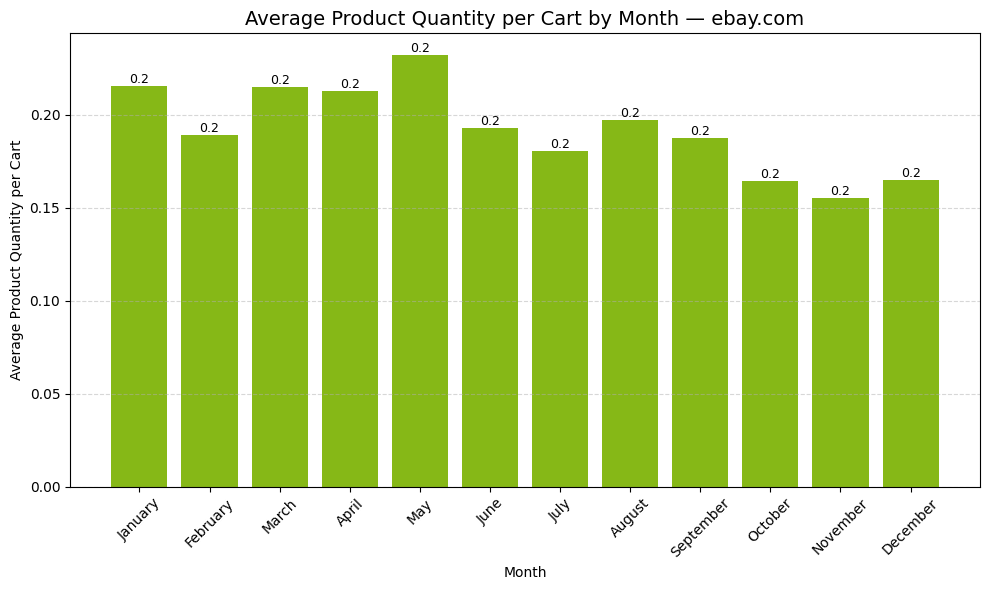

<ipython-input-30-4ba3ea0a31bb>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-30-4ba3ea0a31bb>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


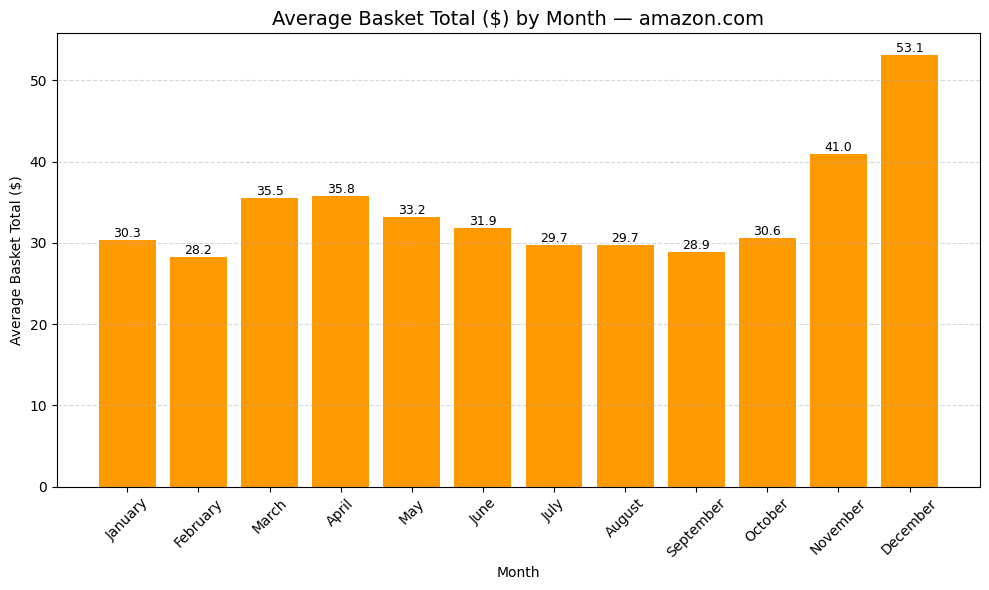

<ipython-input-30-4ba3ea0a31bb>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-30-4ba3ea0a31bb>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


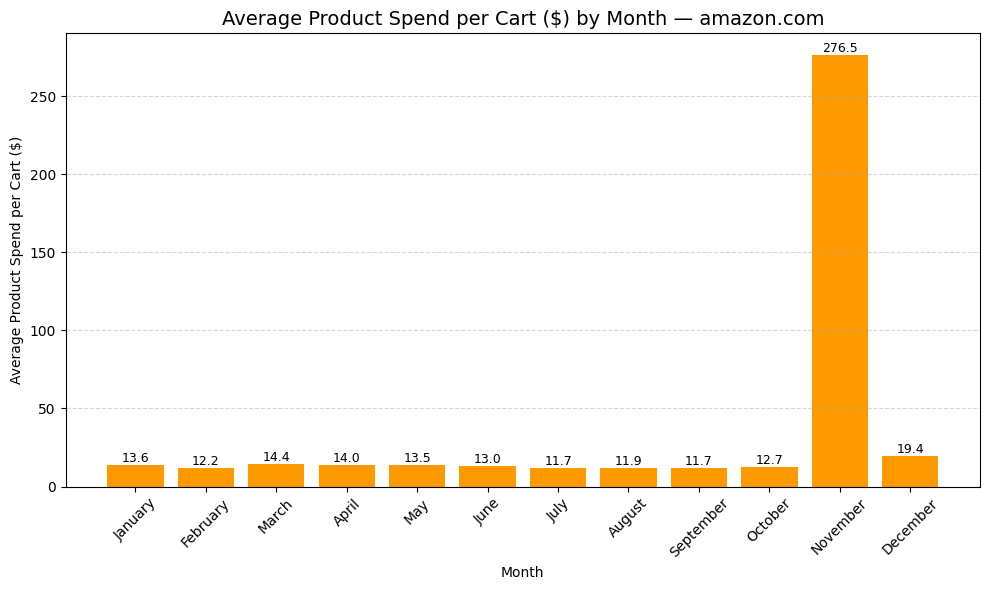

<ipython-input-30-4ba3ea0a31bb>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-30-4ba3ea0a31bb>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


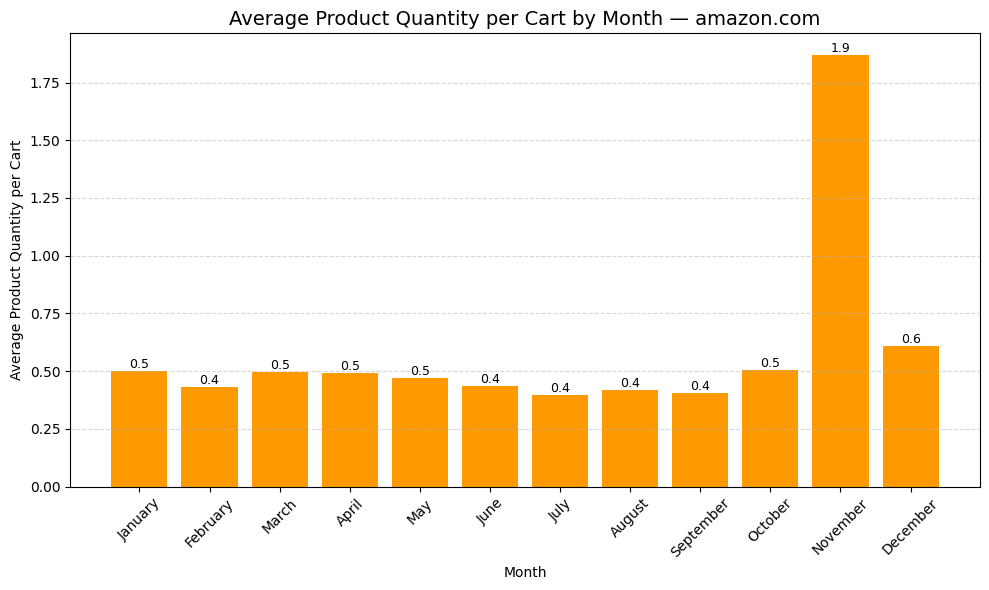

<ipython-input-30-4ba3ea0a31bb>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-30-4ba3ea0a31bb>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


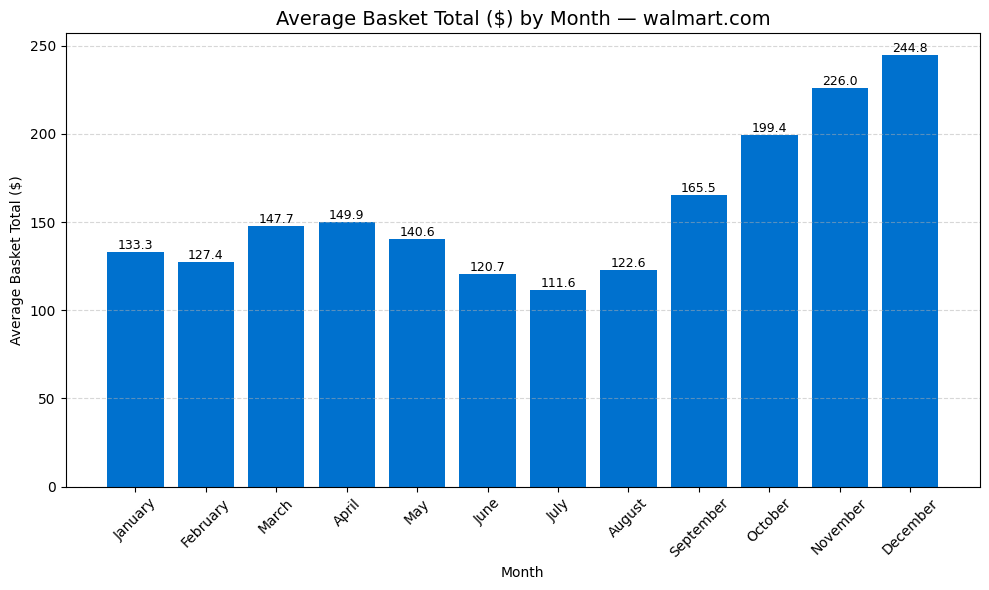

<ipython-input-30-4ba3ea0a31bb>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-30-4ba3ea0a31bb>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


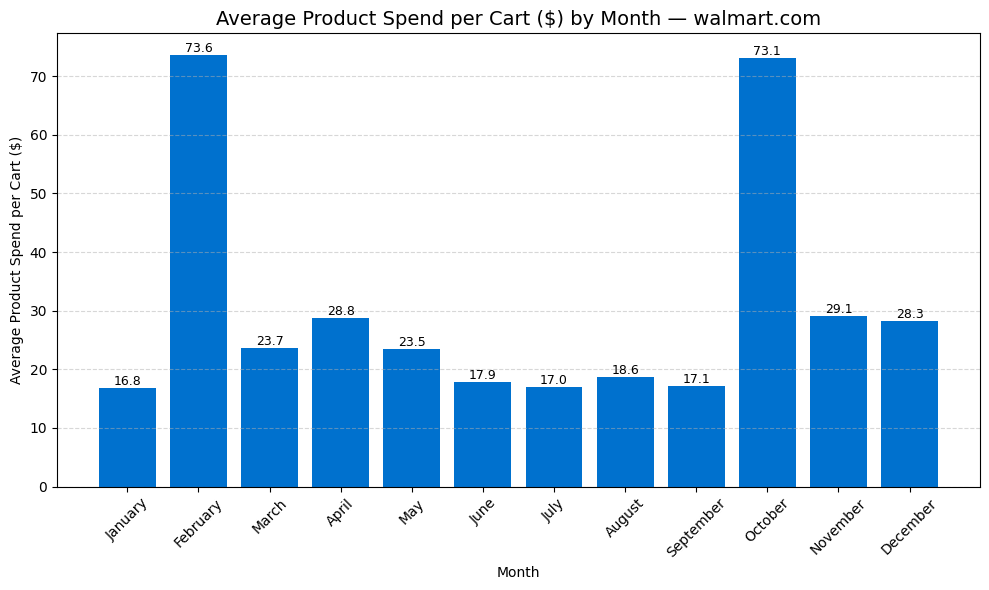

<ipython-input-30-4ba3ea0a31bb>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-30-4ba3ea0a31bb>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


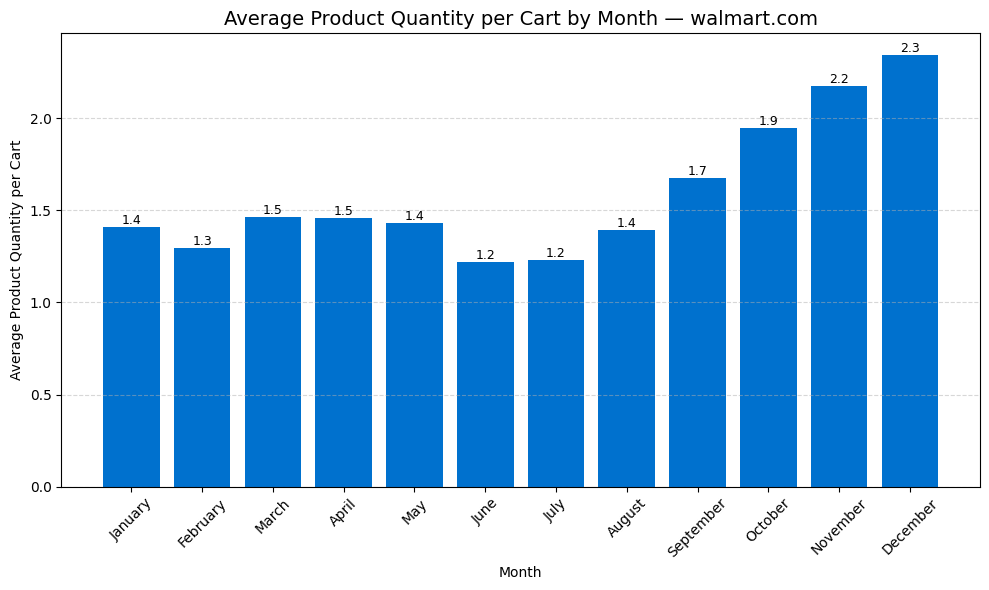

<ipython-input-30-4ba3ea0a31bb>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-30-4ba3ea0a31bb>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


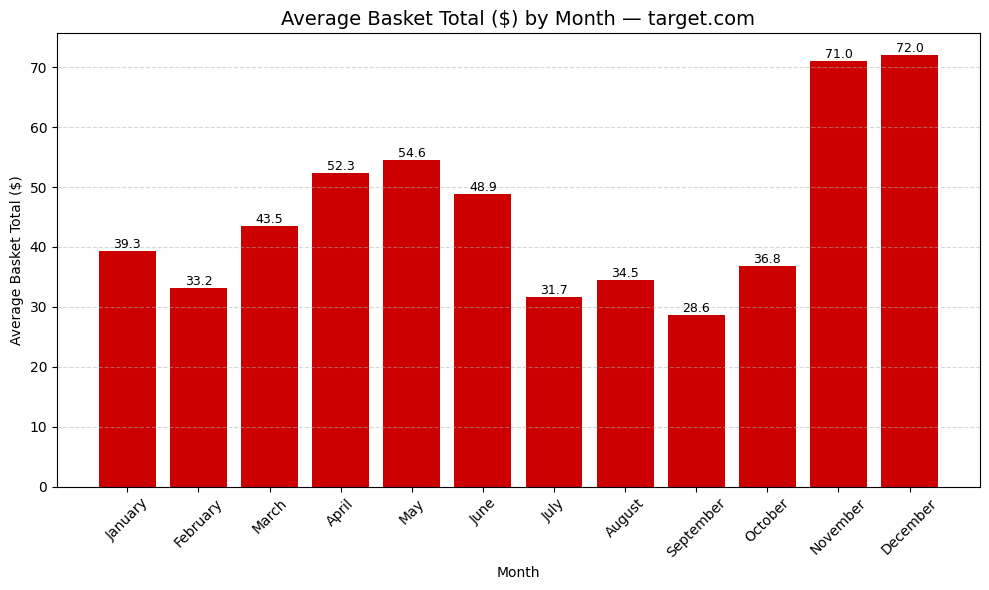

<ipython-input-30-4ba3ea0a31bb>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-30-4ba3ea0a31bb>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


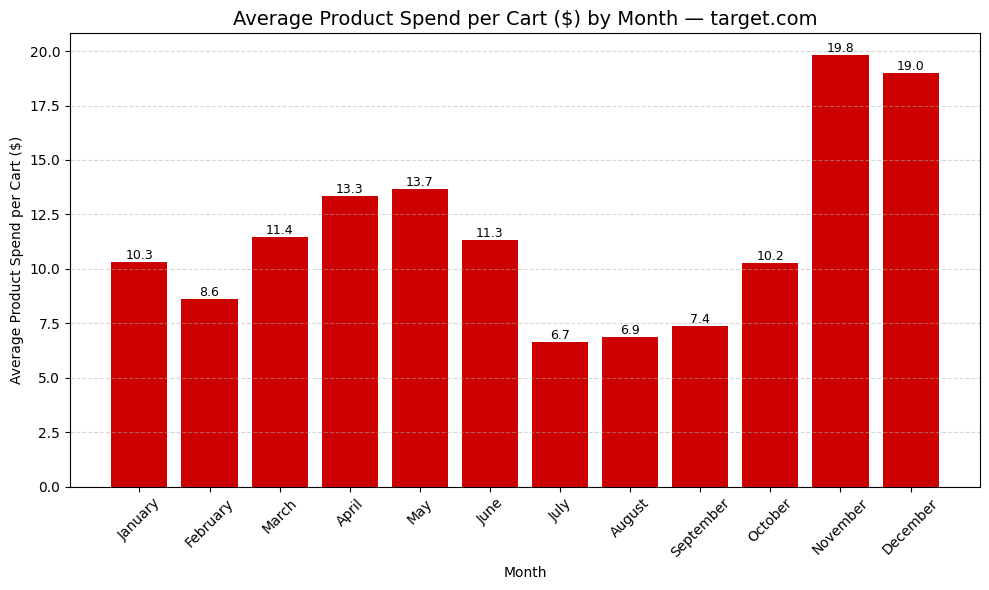

<ipython-input-30-4ba3ea0a31bb>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-30-4ba3ea0a31bb>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


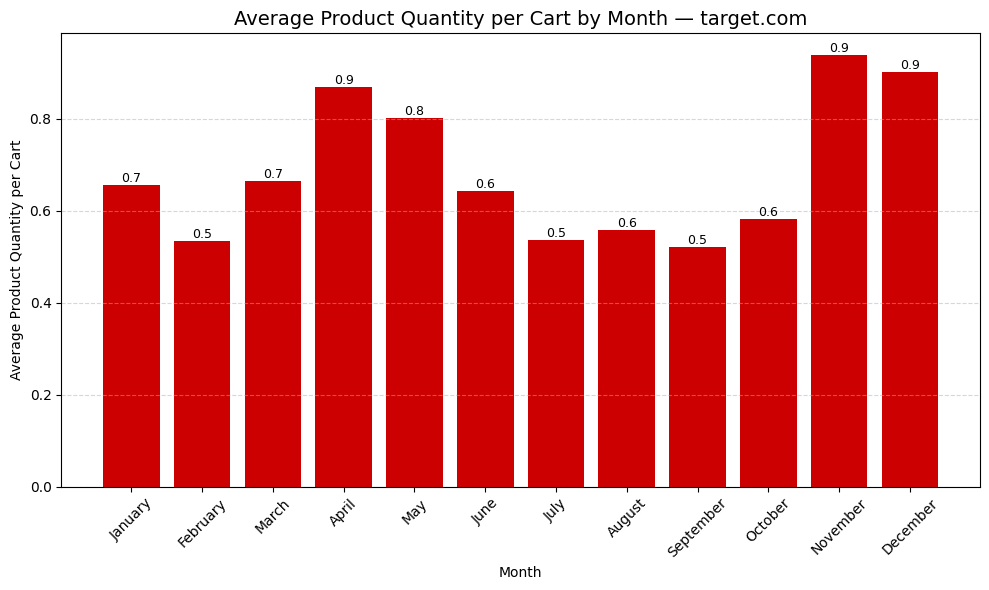

<ipython-input-30-4ba3ea0a31bb>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-30-4ba3ea0a31bb>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


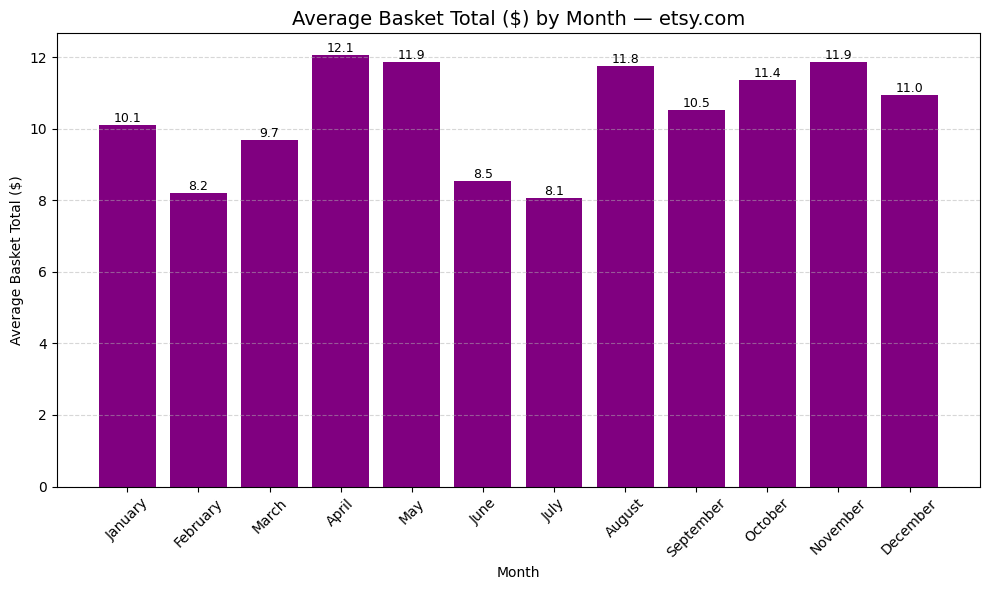

<ipython-input-30-4ba3ea0a31bb>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-30-4ba3ea0a31bb>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


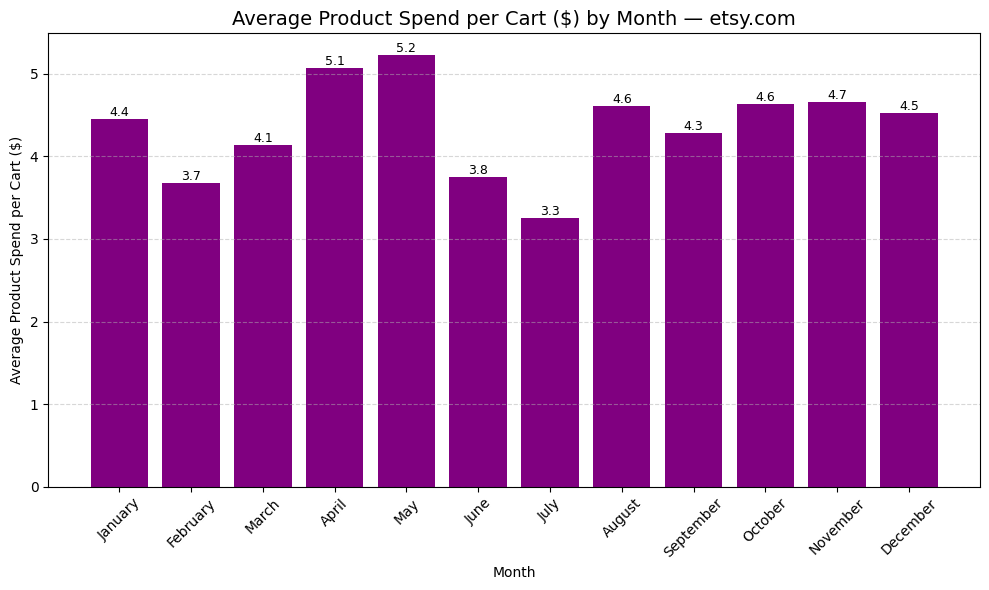

<ipython-input-30-4ba3ea0a31bb>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-30-4ba3ea0a31bb>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


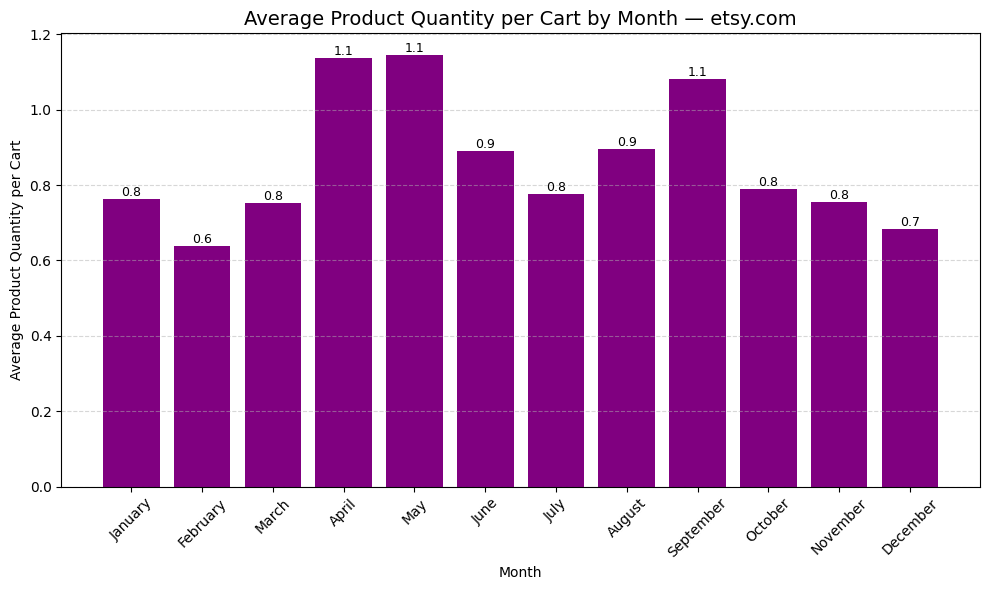

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert event_date to datetime and extract month
transactions['event_date'] = pd.to_datetime(transactions['event_date'])
transactions['month'] = transactions['event_date'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
transactions['month'] = pd.Categorical(transactions['month'], categories=month_order, ordered=True)

# Store domain names and their brand colors
domains = ['ebay.com', 'amazon.com', 'walmart.com', 'target.com', 'etsy.com']
brand_colors = {
    'ebay.com': '#86b817',    # eBay green
    'amazon.com': '#ff9900',  # Amazon orange
    'walmart.com': '#0071ce', # Walmart blue
    'target.com': '#cc0000',  # Target red
    'etsy.com': '#800080'     # Etsy purple
}

# Metrics and labels
metrics = {
    'basket_tot': 'Average Basket Total ($)',
    'prod_totprice': 'Average Product Spend per Cart ($)',
    'prod_qty': 'Average Product Quantity per Cart'
}

# Generate plots
for domain in domains:
    domain_data = transactions[transactions['domain_name'] == domain]
    color = brand_colors[domain]

    for metric, title in metrics.items():
        # Aggregate per cart, then average across all carts for each month
        session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
        monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()

        # Bar plot
        plt.figure(figsize=(10, 6))
        bars = plt.bar(monthly_avg['month'], monthly_avg[metric], color=color)
        plt.title(f'{title} by Month — {domain}', fontsize=14)
        plt.xlabel('Month')
        plt.ylabel(title)
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.5)

        # Add value labels on top of bars
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.1f}',
                     ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        plt.show()


**Ebay:**
- Highest average basketball totals in march, may (16.9 and 17.2)
- Lowest in October - December (10.8,11.0, and 11.8)
    - People are getting family new things during the holidays?

- Average spend per cart
    - Highest in march and may (10.7 and 10.4)
    - Lowest in October through December (7.5, 6.7, 7.1)

- Pretty consistent quantity across the year ~0.2, least in October - December still
- Highest in march - may

HYPOTHESIS: people use eBay to sell their old stuff and not to buy new things
Prime example is selling old stuff during spring cleaning and attracting them to the site, naturally leads to buying things

Meanwhile in Oct - Dec (Holiday’s Season) people are not buying in terms of # or $

**Amazon**

- Highest basketball total on avg in December by a long shot (53.1)
- Lowest in feb and September (28.2 and 28.9)
- Ramps up near the holidays of October - Dec
    - 30.6 —> 41 —> 53

Average Product Spend per Cart is insanely higher in November (267.5) compared to other months ~ 13

Average quantity per cart by month for amazon is also in November at 1.9 versus ~0.5

HYPOTHESIS: people use Amazon to buy Holiday gifts as seen by the huge spikes in quantity and average spending in November

**Walmart**

Average Basket Total
- Highest in holiday season (October - Dec)
    - 199 —> 245
- Lowest in the summer 120 - 111 - 123

Average Product Spend per Month
- Feb = 73.6
- Oct = 73.1
- Lowest in Jan and July (16.8) and 17

Average Quantity
- Highest in Holidays 1.7 —> 2.3 steady increase from Sep to Dec
- Lowest in Summer
    - June + July = 1.2
    - Aug = 1.4
- Feb = 1.3

HYPOTHESIS:
Use Walmart for Halloween + Val Day
Feb low quantity and high price = flowers + candy?
Oct = high price average = costume but abv avg quantity


**Target**

Avg Basket Total
- Highest in nov - dec = 71 + 72
- Increase from feb to June
    - 33 —> 55 in may —> 49 in June

- Lowest in July - September (31.7 —> 29)

Product Spend per Cart
- Highest in nov + dec 20 and 19
- Peak in feb - may again
- 8.6 feb —> 11.4 march —> 13.7 in may

Average Quantity
- 0.9 in April November December —> slightly highest in nov


**Esty**

Lowest average basket total

Avg basket tot
- Highgest in April = 12.1 but consistent from April - may and aug - dec all around 11 - 12 (slight drop in sep from aug to 10.5)

Average Product Spend per Cart
- Highgest in April may (5.1 - 5.2)
- Consistent high in august - dec (4.3-4.7)

Average Product Quantity Per Cart
- Highgest in April may sep ~ 1.1
- Lowest in feb = 0.6



## Normalized

<ipython-input-31-0cf046d92a5d>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-31-0cf046d92a5d>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


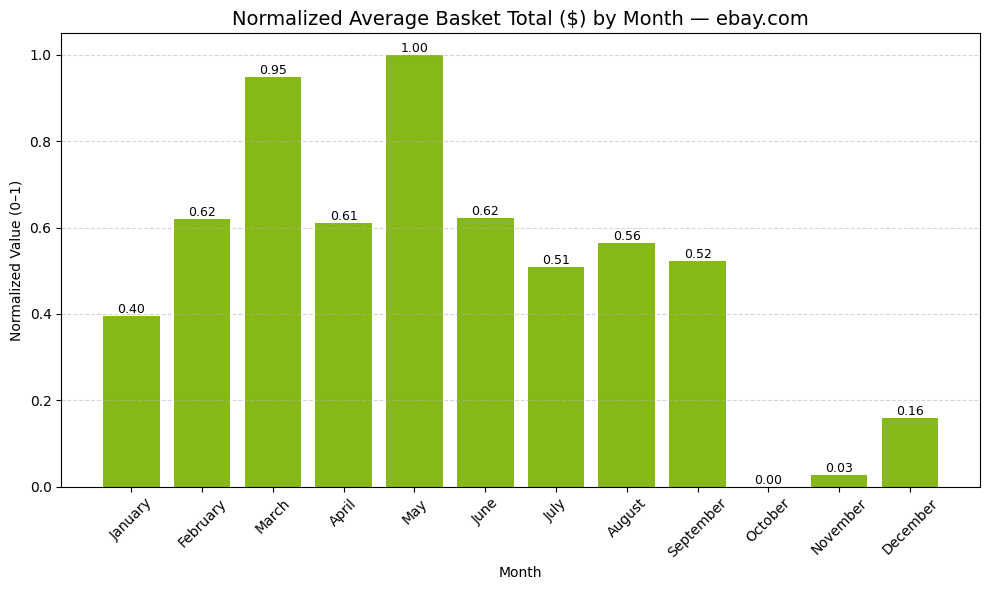

<ipython-input-31-0cf046d92a5d>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-31-0cf046d92a5d>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


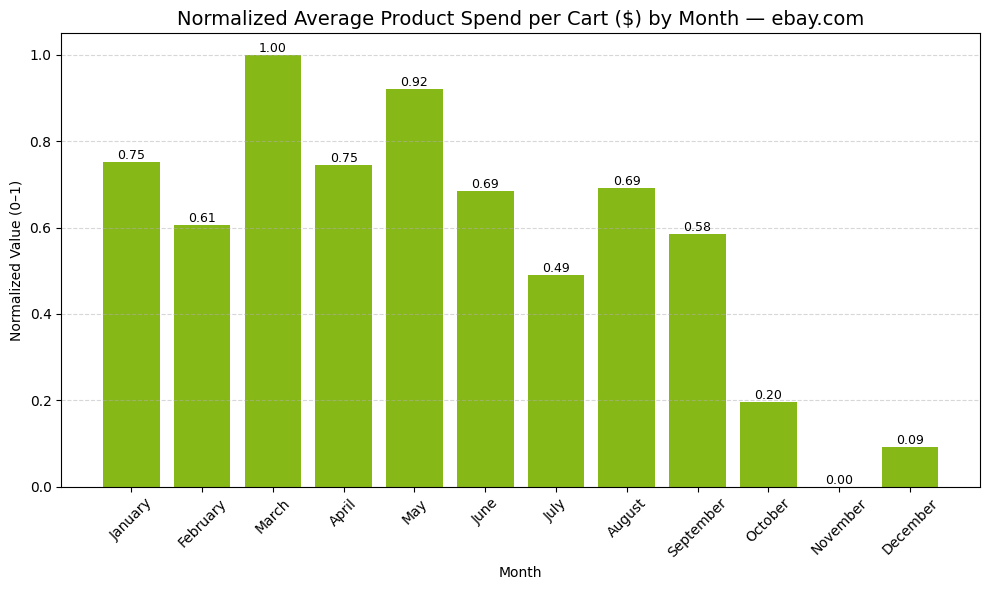

<ipython-input-31-0cf046d92a5d>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-31-0cf046d92a5d>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


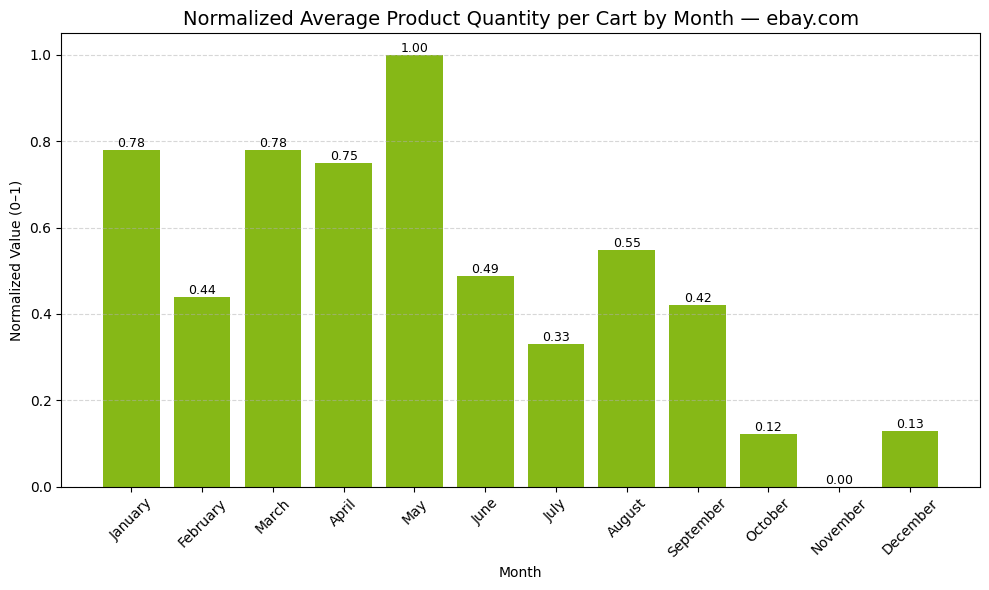

<ipython-input-31-0cf046d92a5d>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-31-0cf046d92a5d>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


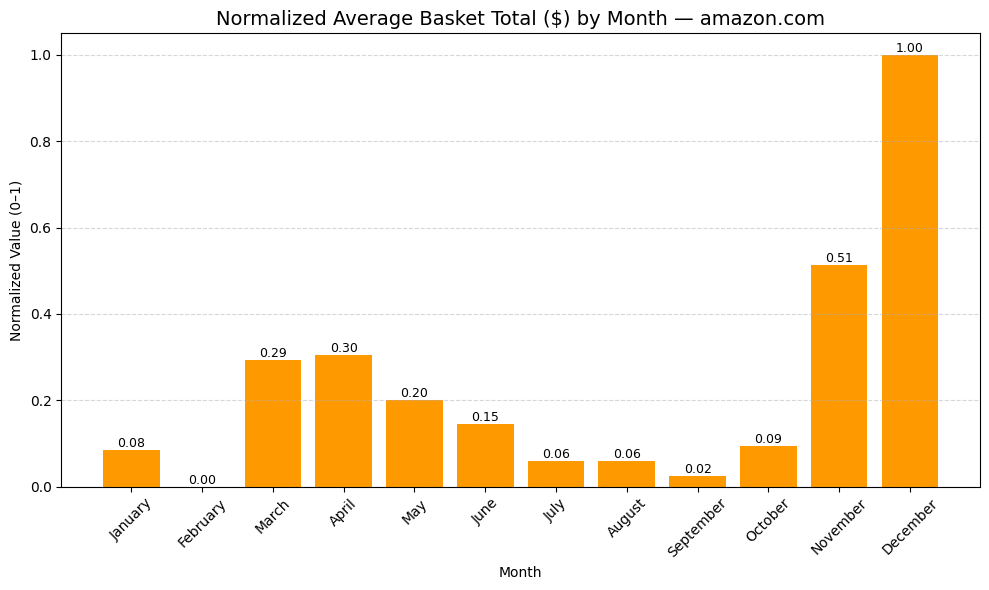

<ipython-input-31-0cf046d92a5d>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-31-0cf046d92a5d>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


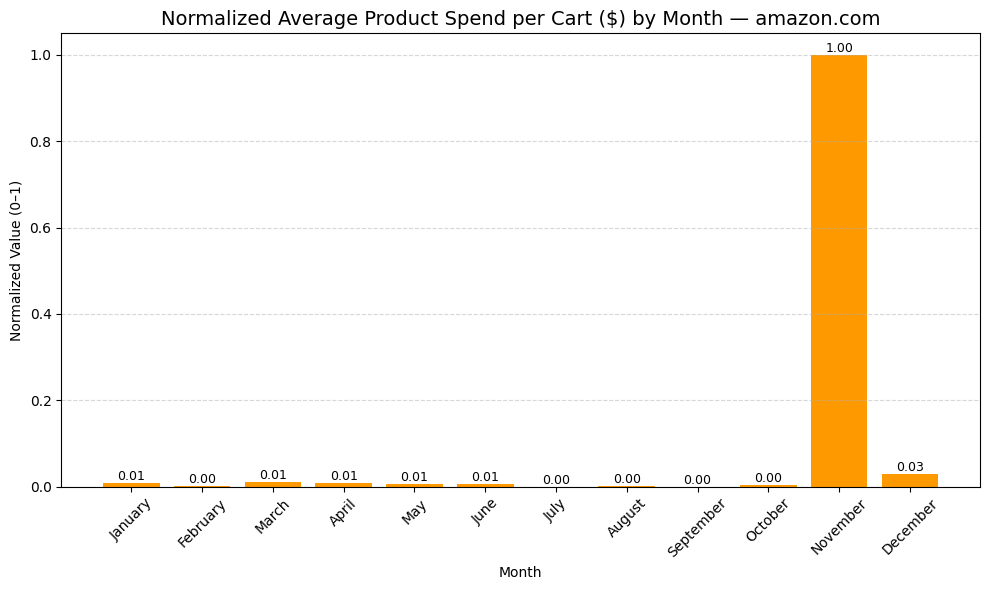

<ipython-input-31-0cf046d92a5d>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-31-0cf046d92a5d>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


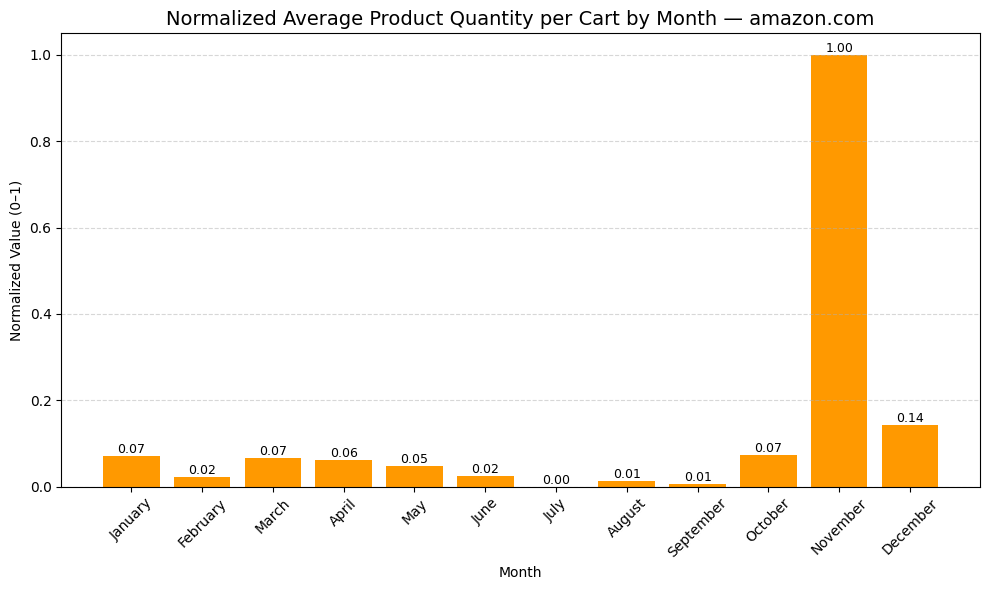

<ipython-input-31-0cf046d92a5d>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-31-0cf046d92a5d>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


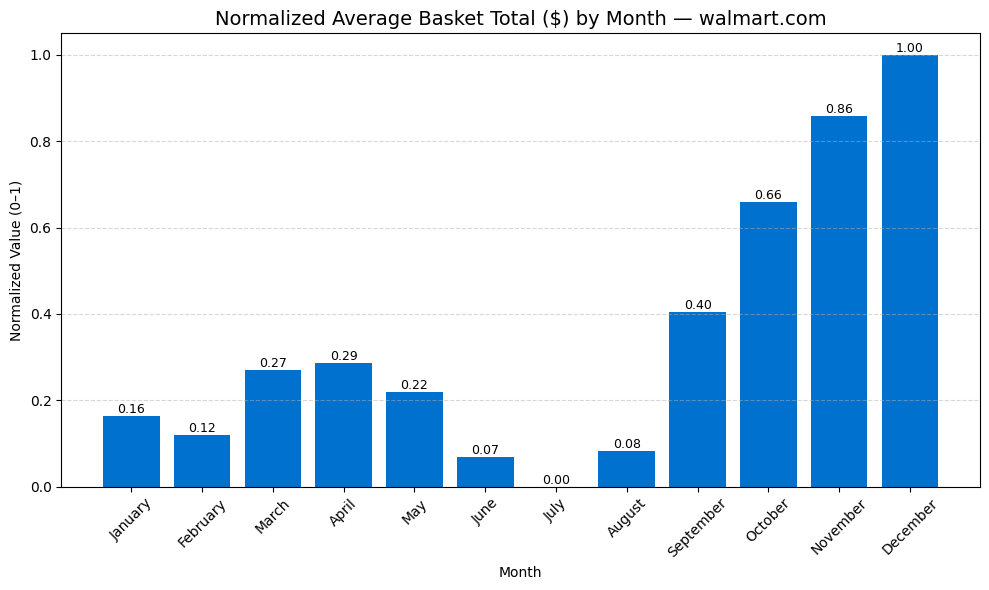

<ipython-input-31-0cf046d92a5d>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-31-0cf046d92a5d>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


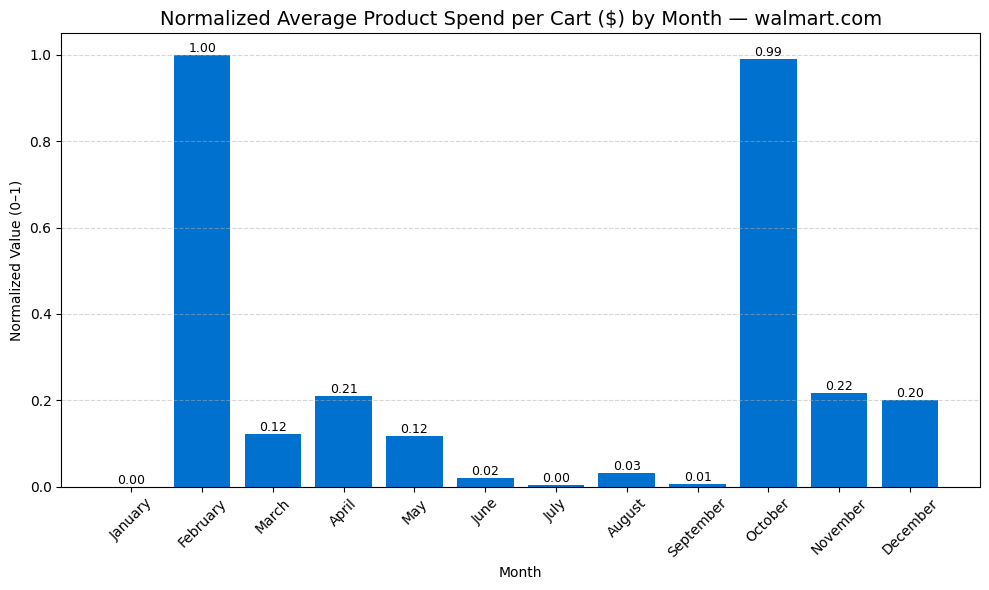

<ipython-input-31-0cf046d92a5d>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-31-0cf046d92a5d>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


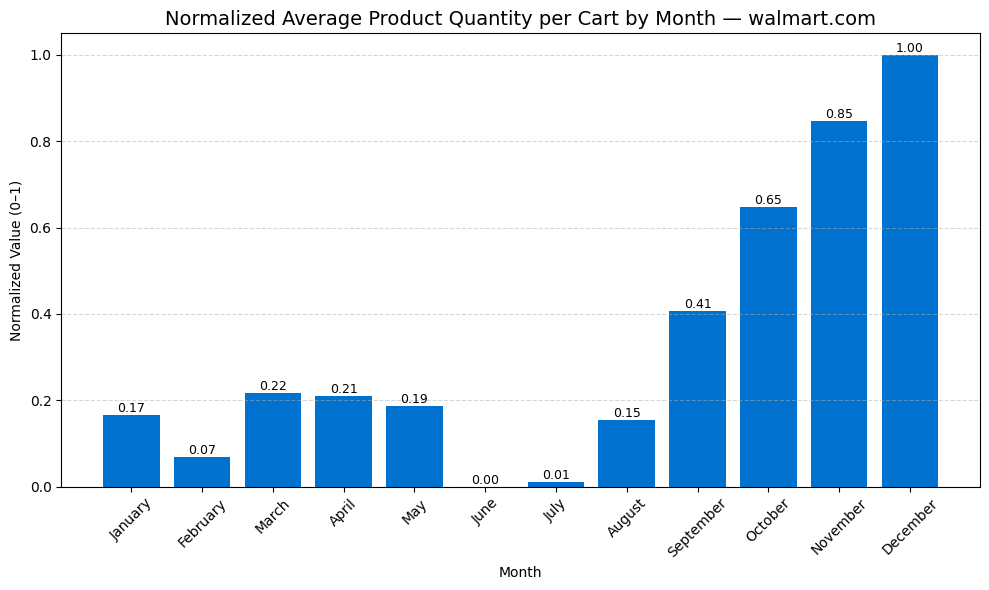

<ipython-input-31-0cf046d92a5d>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-31-0cf046d92a5d>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


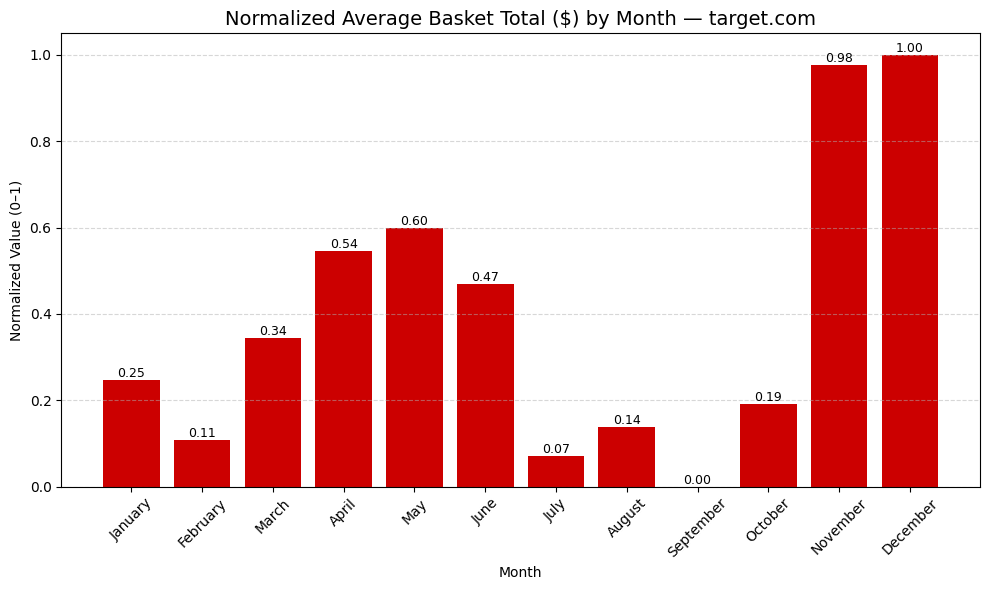

<ipython-input-31-0cf046d92a5d>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-31-0cf046d92a5d>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


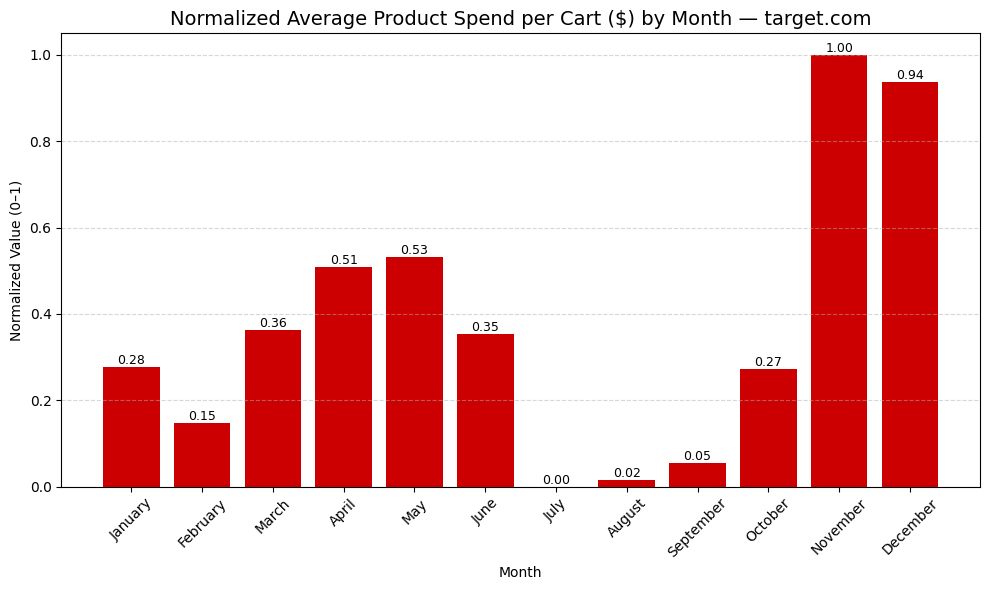

<ipython-input-31-0cf046d92a5d>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-31-0cf046d92a5d>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


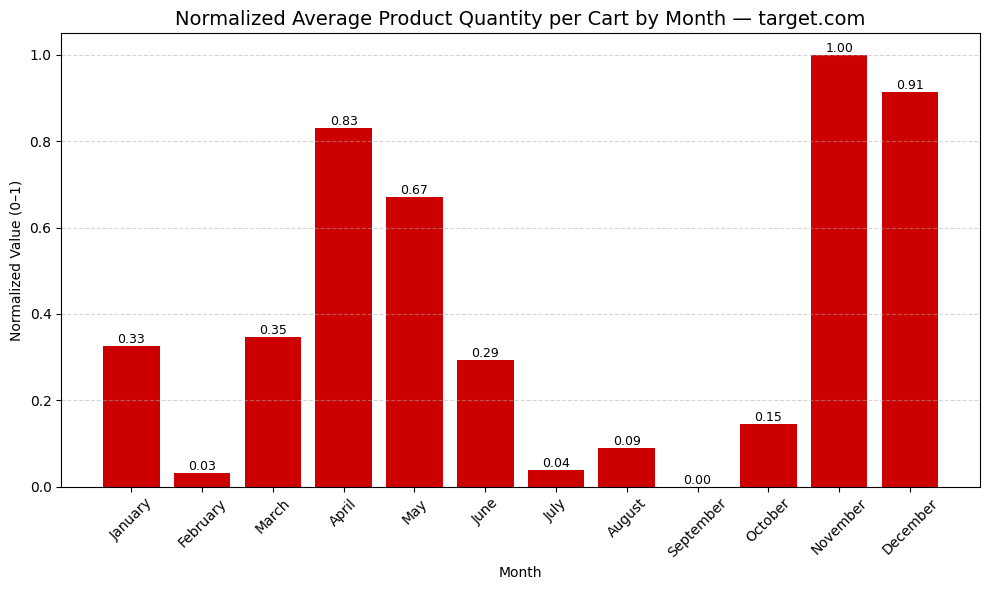

<ipython-input-31-0cf046d92a5d>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-31-0cf046d92a5d>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


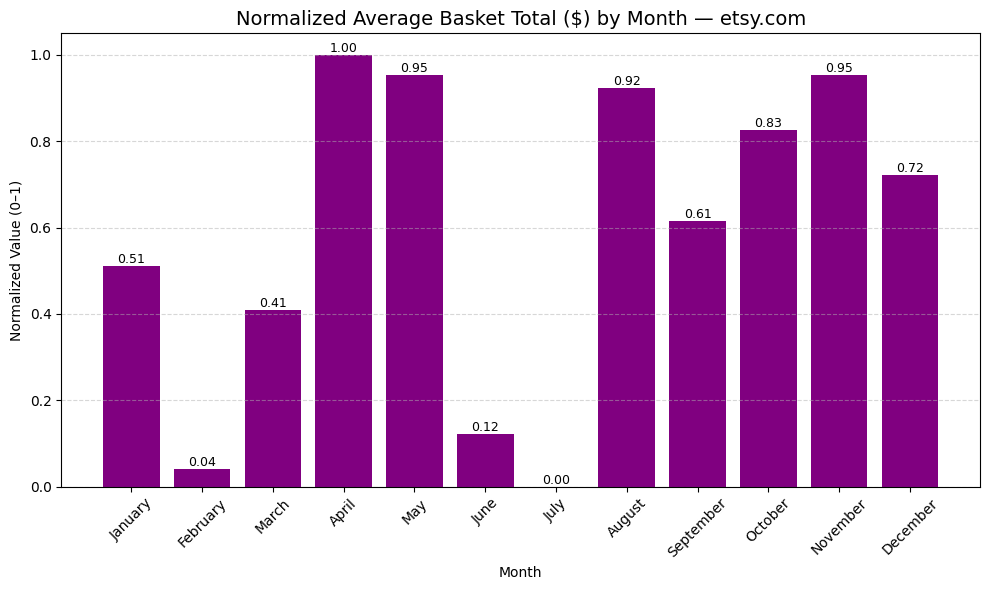

<ipython-input-31-0cf046d92a5d>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-31-0cf046d92a5d>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


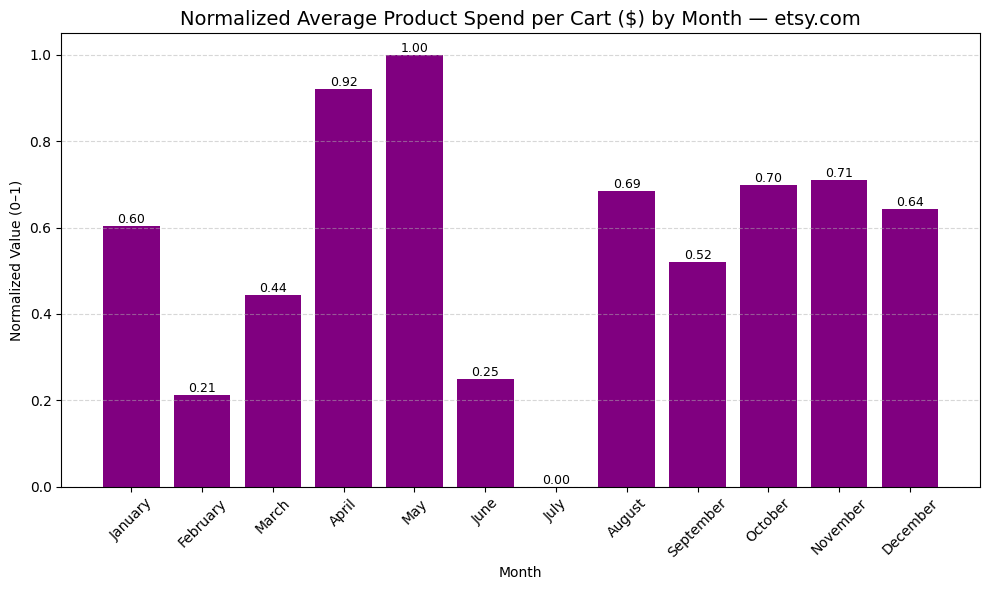

<ipython-input-31-0cf046d92a5d>:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
<ipython-input-31-0cf046d92a5d>:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()


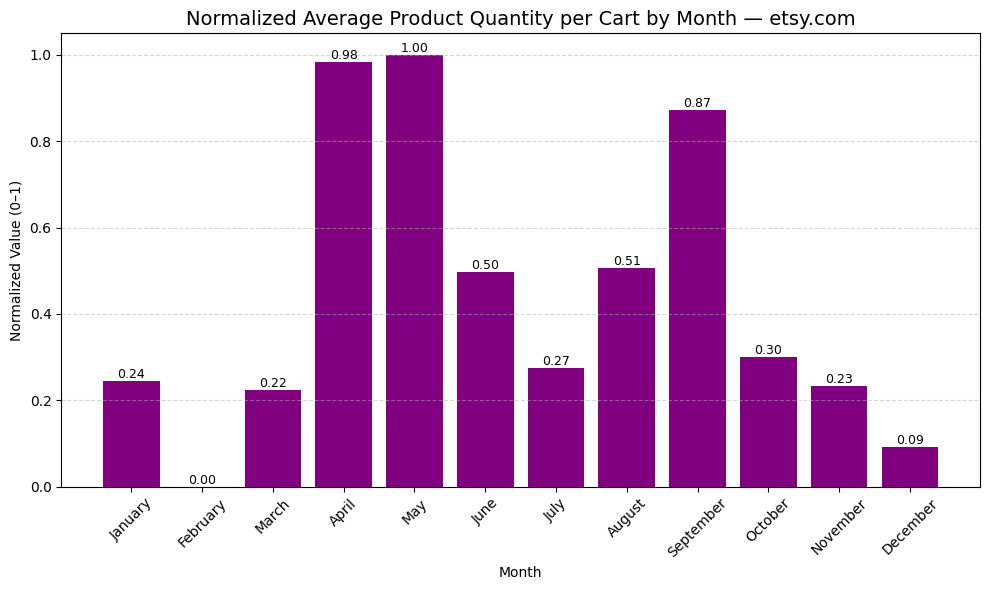

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert event_date to datetime and extract month
transactions['event_date'] = pd.to_datetime(transactions['event_date'])
transactions['month'] = transactions['event_date'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
transactions['month'] = pd.Categorical(transactions['month'], categories=month_order, ordered=True)

# Store domain names and their brand colors
domains = ['ebay.com', 'amazon.com', 'walmart.com', 'target.com', 'etsy.com']
brand_colors = {
    'ebay.com': '#86b817',    # eBay green
    'amazon.com': '#ff9900',  # Amazon orange
    'walmart.com': '#0071ce', # Walmart blue
    'target.com': '#cc0000',  # Target red
    'etsy.com': '#800080'     # Etsy purple
}

# Metrics and labels
metrics = {
    'basket_tot': 'Average Basket Total ($)',
    'prod_totprice': 'Average Product Spend per Cart ($)',
    'prod_qty': 'Average Product Quantity per Cart'
}

# Generate normalized plots
for domain in domains:
    domain_data = transactions[transactions['domain_name'] == domain]
    color = brand_colors[domain]

    for metric, title in metrics.items():
        # Step 1: Aggregate per cart and get monthly averages
        session_metric = domain_data.groupby(['site_session_id', 'month'])[metric].sum().reset_index()
        monthly_avg = session_metric.groupby('month')[metric].mean().reset_index()

        # Step 2: Normalize values
        min_val = monthly_avg[metric].min()
        max_val = monthly_avg[metric].max()
        monthly_avg['normalized'] = (monthly_avg[metric] - min_val) / (max_val - min_val)

        # Step 3: Plot
        plt.figure(figsize=(10, 6))
        bars = plt.bar(monthly_avg['month'], monthly_avg['normalized'], color=color)
        plt.title(f'Normalized {title} by Month — {domain}', fontsize=14)
        plt.xlabel('Month')
        plt.ylabel('Normalized Value (0–1)')
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.5)

        # Add normalized value labels
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.2f}',
                     ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        plt.show()


WHEN NORMALIZED:
Interpreting normalized values is all about relative comparison rather than absolute dollar amounts or quantities. Here's how to break it down

You applied min-max normalization to each domain’s monthly average values. This rescales each metric to a 0–1 range, where:
* 1.0 = the highest monthly average (within that domain and metric)
* 0.0 = the lowest monthly average
* Values between 0 and 1 show how close each month is to those extremes

**Ebay**

Avg Basket Total
- Most = may and march ~ 0.95 and 1.00
- Least = October and November = 0 and 0.03

Avg Product Spend
— Most = March + May = 1.00 and 0.92
— Least = November and December

Avg Prod Qty
— Most = May = 1.00
— Least = Nov = 0.00

**Amazon**

Avg Basket Total
— Most = Dec = 1 and 0.51 = Nov
	jumpy between feb and march - April
— Least = Feb = 0 and Sep = 0.02, in general 0 - 0.30 but jumps in nov

Avg Product Spend
- Clearly in nov = 1.00
- Least = July + Sep = 0.00

Note amazon prime day = July and October

Avg Prod Qty
- Nov = 1.00 and least in July 0.00 - sep 0.01

**Walmart**

Avg Basket Total
- Most = 1.00 in Dec Nov = 0.86
- Least = July = 0.00

Avg Product Spend
- Most = Feb and October = 1 and 0.99
- Least = July and Jan = 0.00 and September 0.01

Avg Prod Qty
- Most = Dec = 1.00 and Nov 0.85 and Oct 0.65
- Least = June and July 0 and 0.01

**Target**

Avg Basket Total
- Most = Nov and Dec = 0.98 and 1.00
- Least = Sep = 0

Avg Product Spend
- Most = Nov = 1.00 and Dec 0.94
- July = 0.00

Avg Prod Qty
- Most = Nov 1.00 and Dec = 0.91
- Least = Sep = 0.00 and Feb 0.03 and July 0.04

**Etsy**

Avg Basket Total
— most = April = 1 may and nov = 0.95 aug = 0.92
- Least = july = 0 and feb = 0.04

Avg Product Spend
- Most = may = 1.00 and April = 0.92
- Least = July = 0

Avg Prod Qty
- Most = April May = 0.98 and 1.00
- Least = Feb = 0

TODO:
Potential research question — who’s the best performer by quarter and why?
- K means what affects whether people buy or not
- Quantity v Price


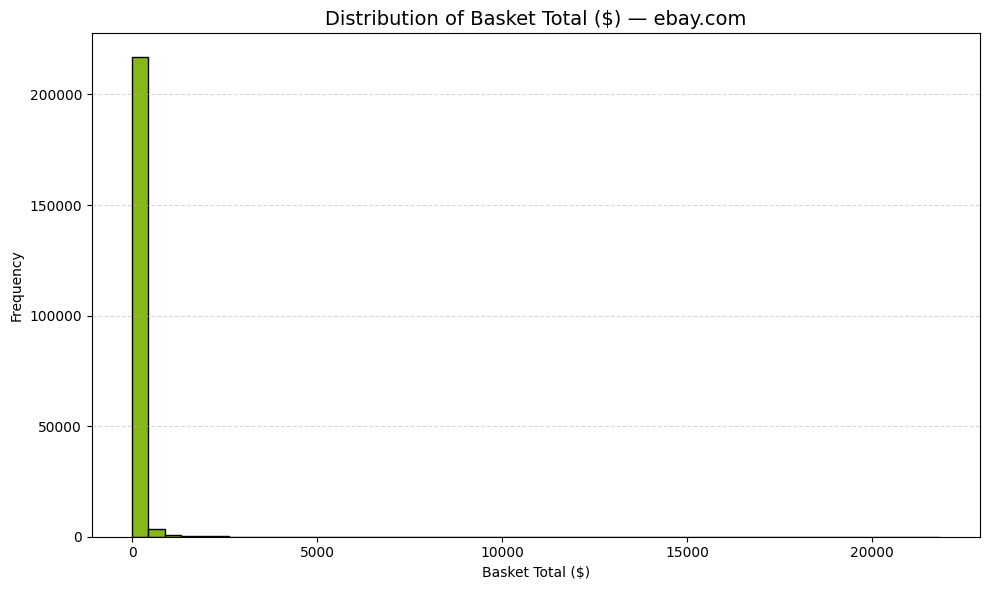

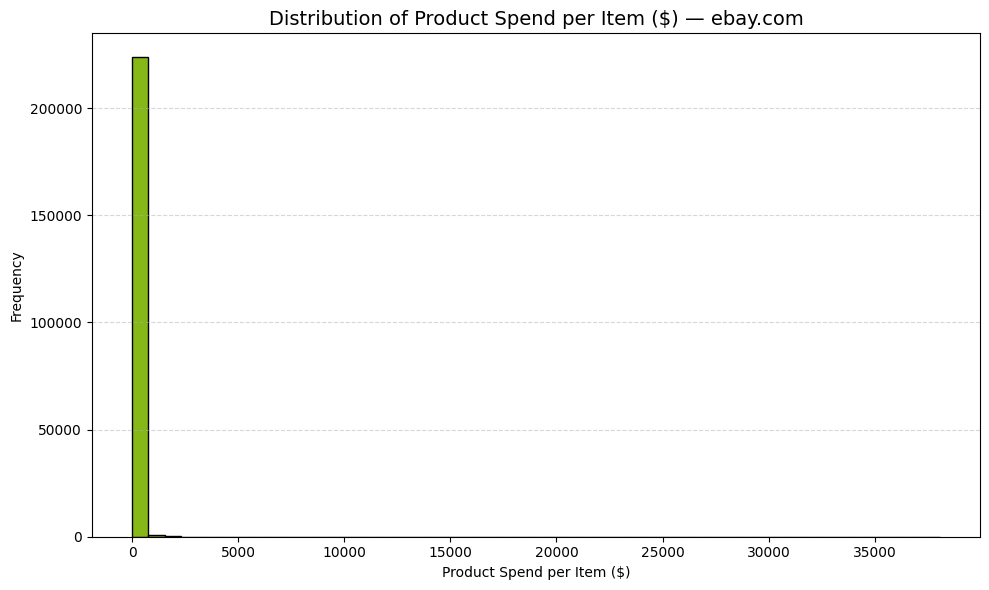

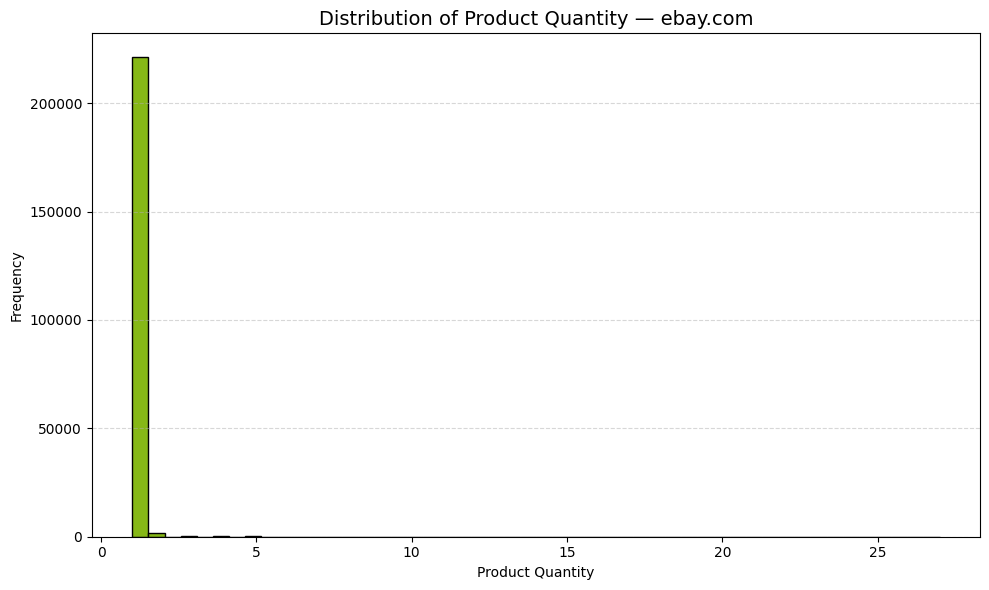

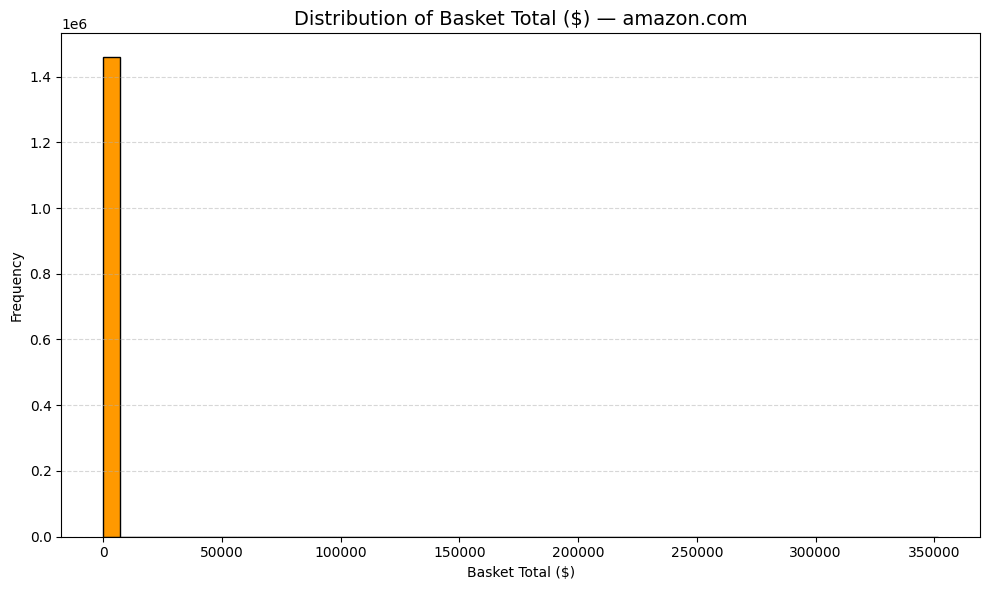

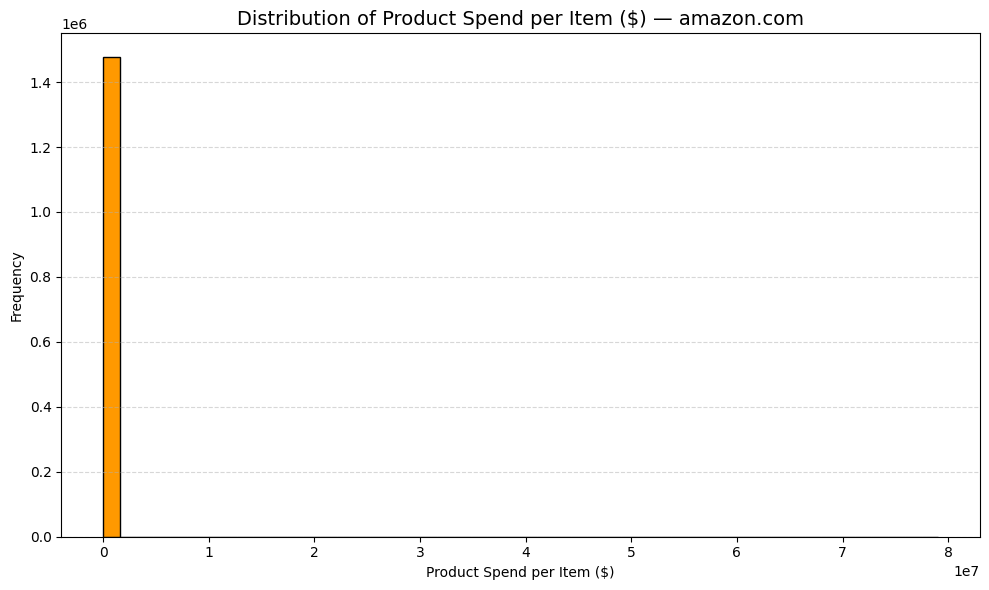

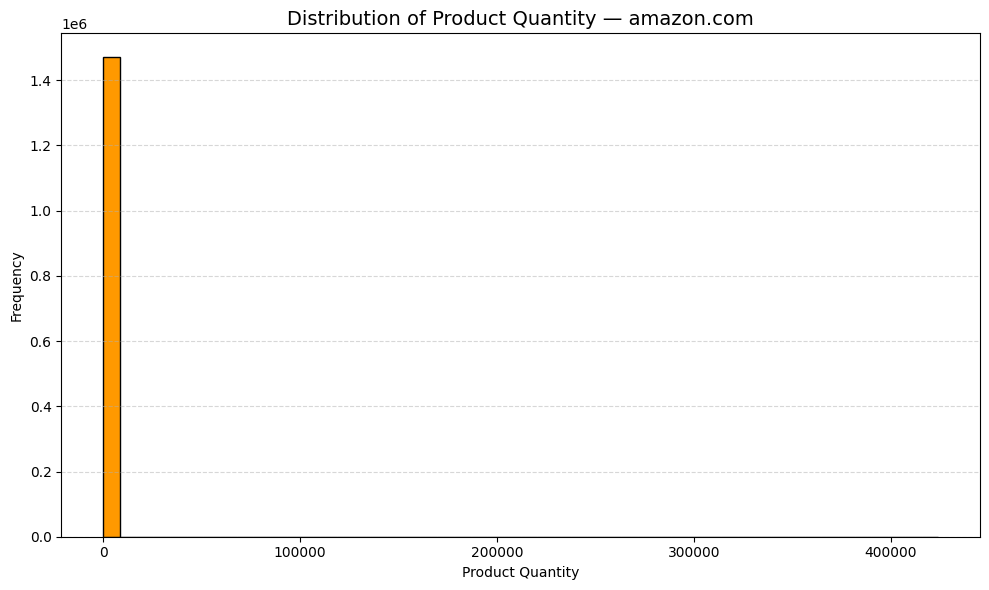

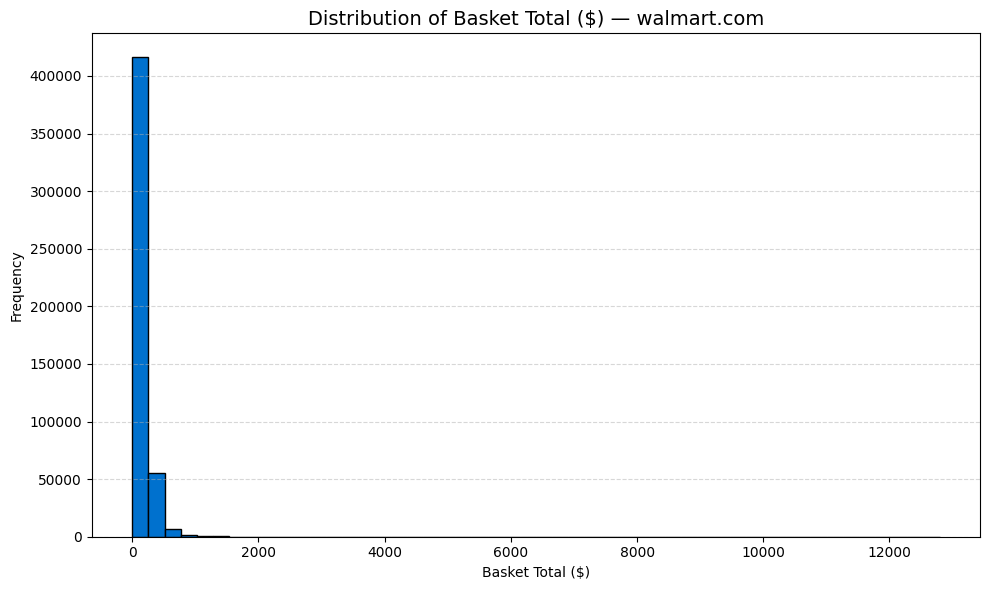

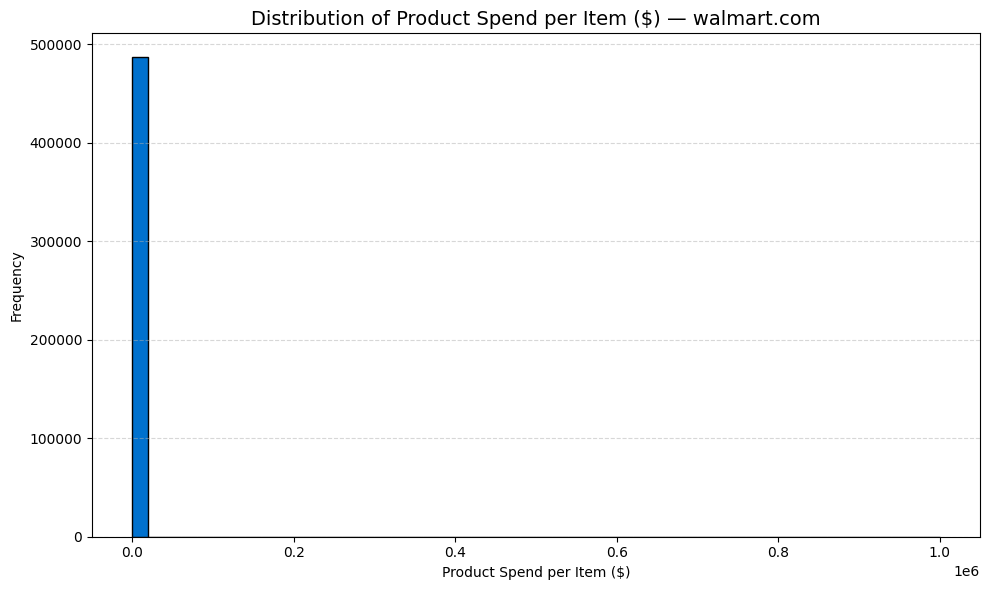

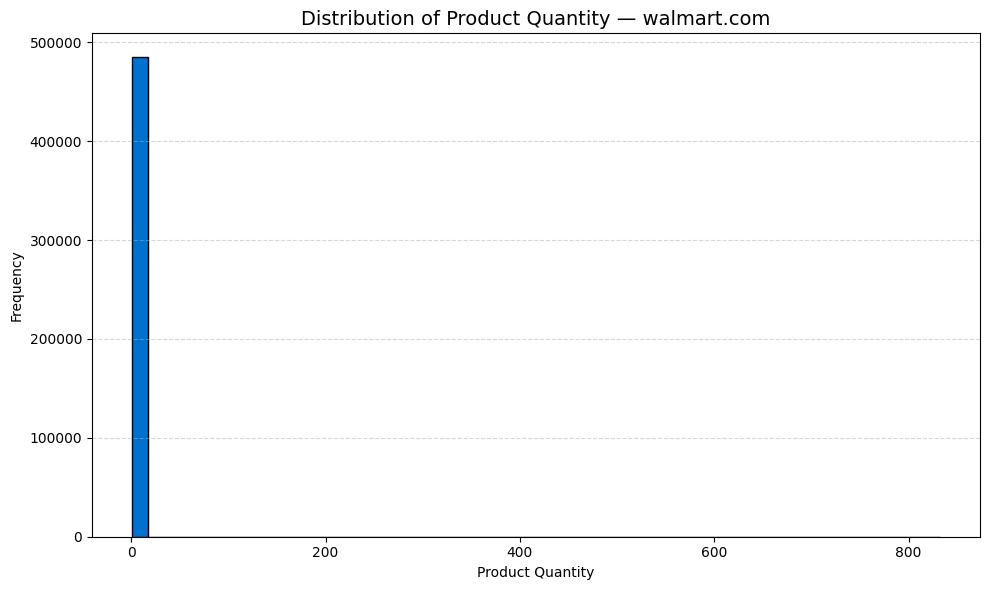

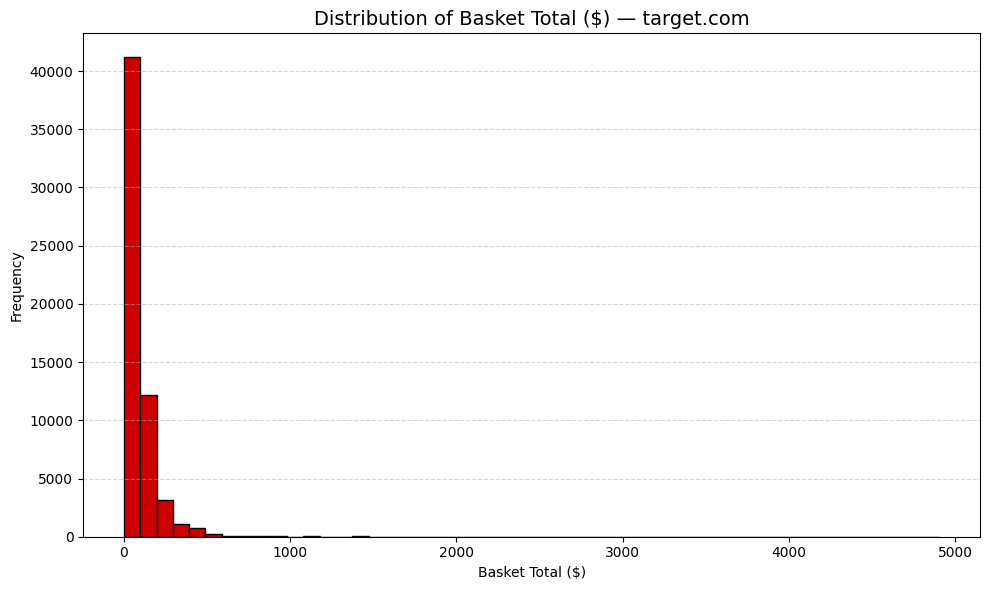

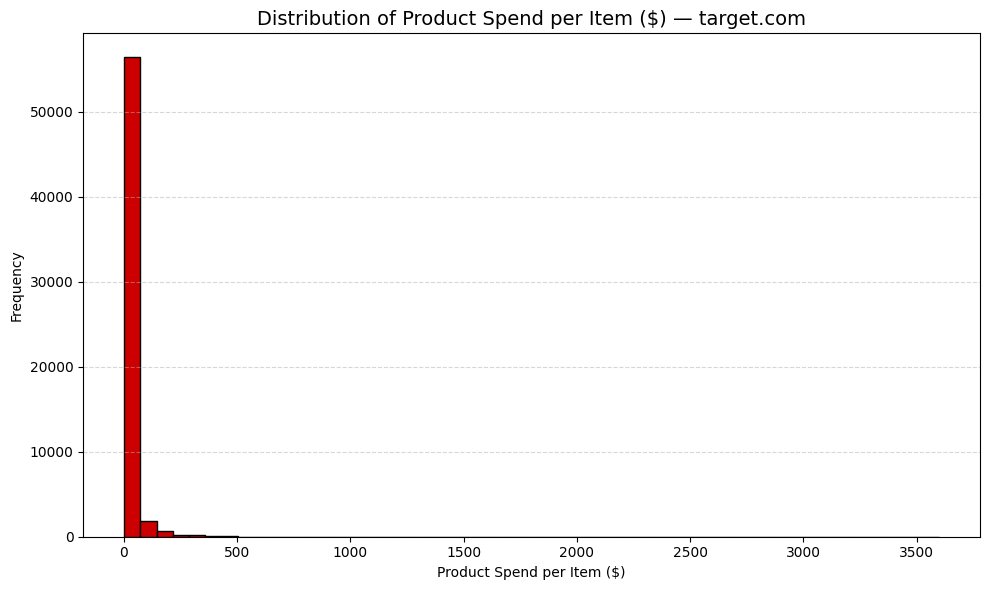

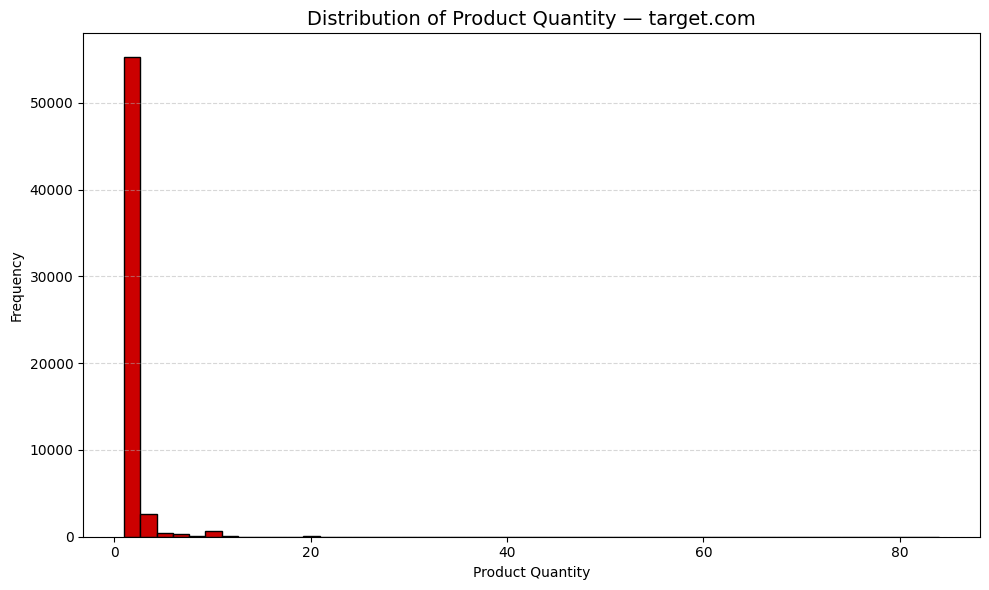

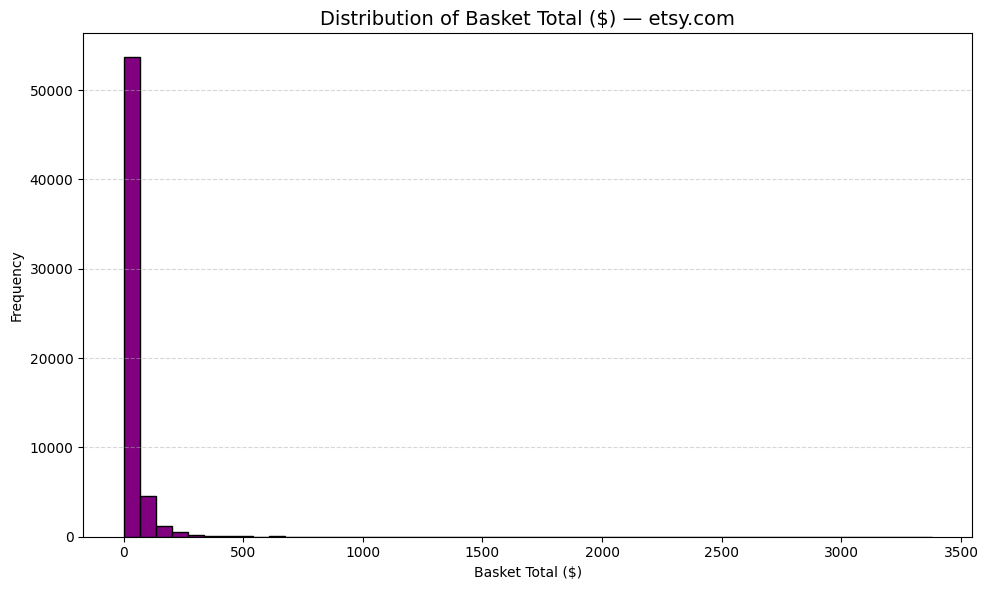

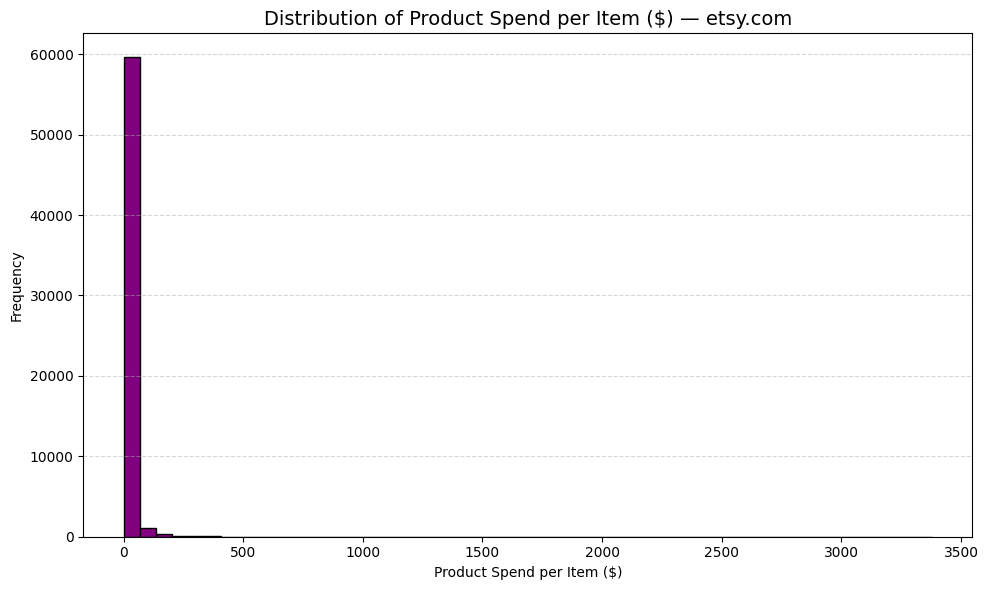

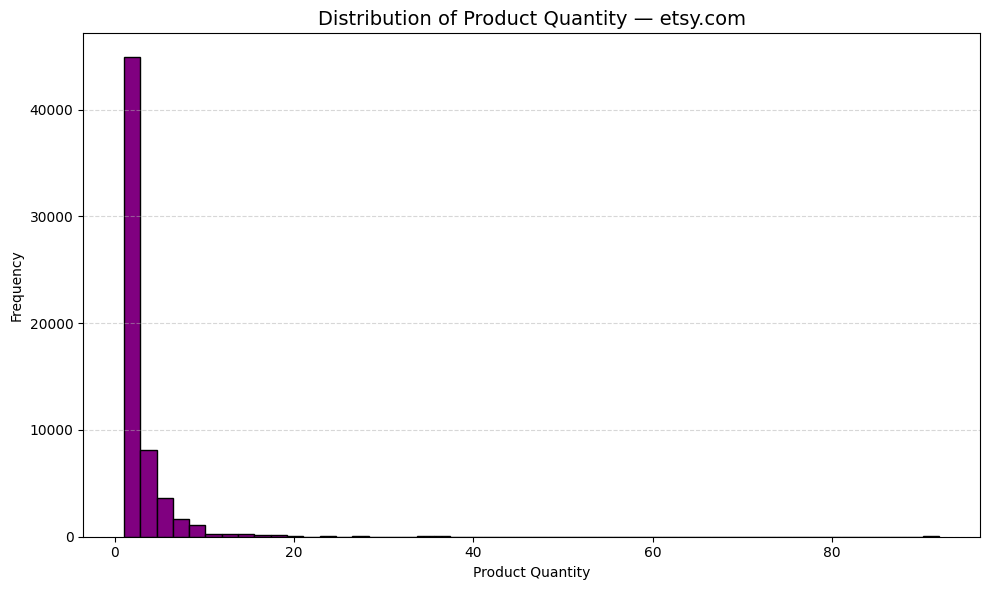

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert event_date to datetime
transactions['event_date'] = pd.to_datetime(transactions['event_date'])

# Define domains and colors
domains = ['ebay.com', 'amazon.com', 'walmart.com', 'target.com', 'etsy.com']
brand_colors = {
    'ebay.com': '#86b817',    # eBay green
    'amazon.com': '#ff9900',  # Amazon orange
    'walmart.com': '#0071ce', # Walmart blue
    'target.com': '#cc0000',  # Target red
    'etsy.com': '#800080'     # Etsy purple
}

# Metrics to plot
metrics = {
    'basket_tot': 'Basket Total ($)',
    'prod_totprice': 'Product Spend per Item ($)',
    'prod_qty': 'Product Quantity'
}

# Plot distributions
for domain in domains:
    domain_data = transactions[transactions['domain_name'] == domain]
    color = brand_colors[domain]

    for metric, title in metrics.items():
        plt.figure(figsize=(10, 6))
        plt.hist(domain_data[metric].dropna(), bins=50, color=color, edgecolor='black')
        plt.title(f'Distribution of {title} — {domain}', fontsize=14)
        plt.xlabel(title)
        plt.ylabel('Frequency')
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()


In [ ]:
!cp "/content/drive/MyDrive/Colab_Notebooks/WUDAC_Datathon.ipynb" "/content/WUDAC_Datathon.ipynb"
!jupyter nbconvert --to html "/content/WUDAC_Datathon.ipynb"

from google.colab import files
files.download('/content/WUDAC_Datathon.html')

[NbConvertApp] Converting notebook /content/WUDAC_Datathon.ipynb to html
[NbConvertApp] Writing 766714 bytes to /content/WUDAC_Datathon.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Data Featurization for K Means

# Data Cleaning

In [ ]:
transactions['machine_id'].value_counts()

,count
machine_id,
299486121,7679
327816037,7287
350847623,3271
312552060,2889
319415980,2857
...,...
288350482,1
300925937,1
289970321,1


median qty, median amt purchased, median links

psuedo user database for machine_id as a person / user -- use k means to cluster behavior

In [ ]:
ebay = transactions[transactions['domain_name'] == 'ebay.com']
ebay_users = ebay.groupby("machine_id")[['prod_qty', 'prod_totprice', 'basket_tot']].median()
ebay_users

,prod_qty,prod_totprice,basket_tot
machine_id,,,
100026976,1.0,36.570,43.210
104679635,1.0,29.950,44.040
123005549,1.0,20.990,22.380
125868675,1.0,17.700,23.295
127271257,1.0,14.990,15.930
...,...,...,...
371322044,1.0,4.930,7.360
371390606,1.0,21.495,23.160
371465491,1.0,10.000,14.525


Text(0.5, 1.0, 'Distribution of Purchases by Machine ID')

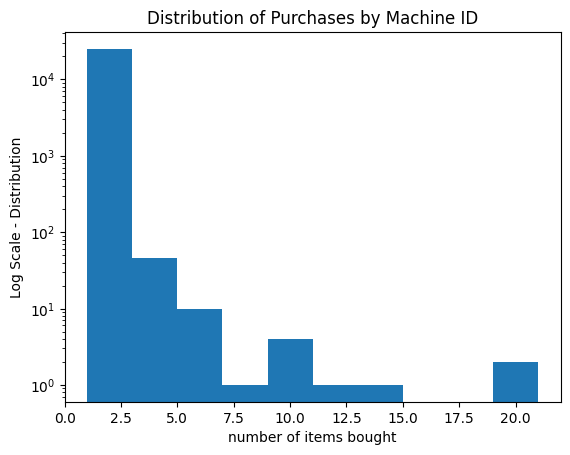

In [ ]:
plt.hist(ebay_users['prod_qty'])
plt.yscale("log")
plt.xlabel("number of items bought")
plt.ylabel("Log Scale - Distribution")
plt.title("Distribution of Purchases by Machine ID")

Text(0.5, 1.0, 'Distribution of Item Price by Machine ID')

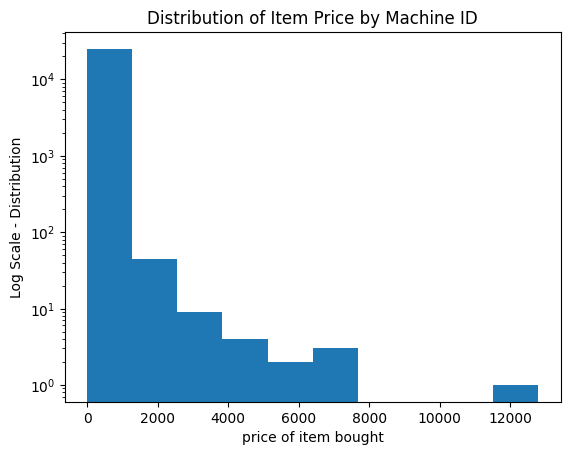

In [ ]:
plt.hist(ebay_users['prod_totprice'])
plt.yscale("log")
plt.xlabel("price of item bought")
plt.ylabel("Log Scale - Distribution")
plt.title("Distribution of Item Price by Machine ID")

Text(0.5, 1.0, 'Distribution of Basket Total by Machine ID')

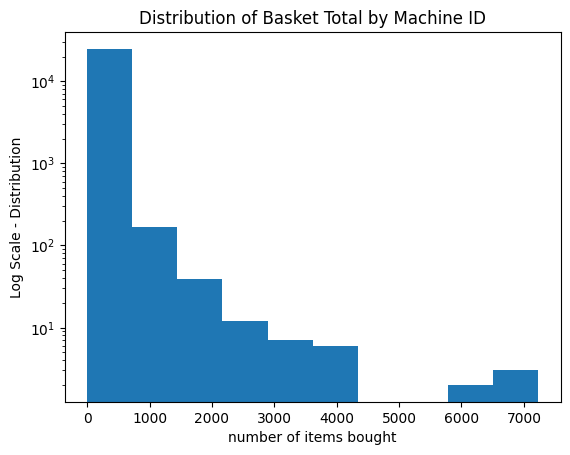

In [ ]:
plt.hist(ebay_users['basket_tot'])
plt.yscale("log")
plt.xlabel("number of items bought")
plt.ylabel("Log Scale - Distribution")
plt.title("Distribution of Basket Total by Machine ID")

In [ ]:
test = transactions[transactions['machine_id'] == 319415980]
test['domain_name'].value_counts()

,count
domain_name,
walmart.com,2052
amazon.com,531
target.com,191
ebay.com,80
etsy.com,3


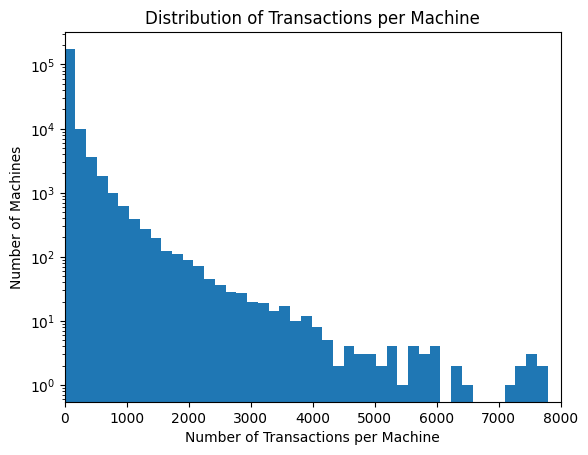

In [ ]:
import matplotlib.pyplot as plt

# Get the number of transactions per machine
counts = sessions['machine_id'].value_counts()

# Plot the histogram of how many times each count occurs
plt.hist(counts, bins=50)
plt.yscale("log")

# Limit the x-axis to ignore outliers (e.g., 0–100 transactions)
plt.xlim(0, 8000)

plt.xlabel('Number of Transactions per Machine')
plt.ylabel('Number of Machines')
plt.title('Distribution of Transactions per Machine')
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Get the number of transactions per machine
counts = sessions['transactions'].value_counts()

# Plot the histogram of how many times each count occurs
plt.hist(counts, bins=50)
plt.yscale("log")

# Limit the x-axis to ignore outliers (e.g., 0–100 transactions)
plt.xlim(0, 8000)

plt.xlabel('Number of Transactions per Machine')
plt.ylabel('Number of Machines')
plt.title('Distribution of Transactions per Machine')
plt.show()


KeyError: 'transactions'

In [ ]:
plt.plot()

KeyError: 'machine_id'

In [ ]:
transactions = transactions[['site_session_id','prod_category_id', 'prod_qty', 'prod_totprice', 'basket_tot', 'event_date', 'event_time','domain_name', 'total_transactions_2020', 'total_transactions_2021', 'total_transactions_2022', 'total_transactions_2023', 'month']]

In [ ]:
sessions['ref_domain__name'].value_counts()

,count
ref_domain__name,
amazon.com,1602311
google.com,507060
ebay.com,457905
bing.com,310356
yahoo.com,183239
...,...
dlink.com,1
preguntados.com,1
newsru.com,1


# Exploring User Behavior

In [ ]:
sessions_new = sessions.head(500000)

In [ ]:
# 	Merge sessions + transactions on site_session_id
transactions = transactions.drop(columns=["event_date", "event_time", "domain_name"], errors='ignore')
merged_df = sessions_new.merge(transactions, on="site_session_id", how="right")

In [ ]:
# If basket_tot is not null, user made a purchase
# merged_df['made_purchase'] = merged_df['basket_tot'].notna().astype(int)

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2309358 entries, 0 to 2309357
Data columns (total 29 columns):
 #   Column                   Dtype   
---  ------                   -----   
 0   machine_id               float64 
 1   site_session_id          int64   
 2   user_session_id          float64 
 3   domain_id                float64 
 4   ref_domain__name         object  
 5   pages_viewed             float64 
 6   duration                 float64 
 7   event_date               object  
 8   event_time               object  
 9   hoh_most_education       float64 
 10  census_region            float64 
 11  household_size           float64 
 12  hoh_oldest_age           float64 
 13  household_income         float64 
 14  children                 float64 
 15  racial_background        float64 
 16  connection_speed         float64 
 17  hispanic                 float64 
 18  zip_code                 float64 
 19  domain_name              object  
 20  prod_category_id        

In [ ]:
test = merged_df[['site_session_id', 'event_date']]
test = test[(test['event_date'] >= "2021-01-01") & (test['event_date'] <= "2022-01-01")]
test

,site_session_id,event_date


## note: user_session_id v site_session_id

In [ ]:
merged_df

,machine_id,site_session_id,user_session_id,domain_id,ref_domain__name,pages_viewed,duration,event_date,event_time,hoh_most_education,...,domain_name,prod_category_id,prod_qty,prod_totprice,basket_tot,total_transactions_2020,total_transactions_2021,total_transactions_2022,total_transactions_2023,month
0,285811167.0,7837313750729559995,2.412858e+15,4.046670e+18,NaN,4.0,3.0,2020-01-01,0:00:02,2.0,...,amazon.com,1001001014,1.0,15.66,593.07,69.0,NaN,NaN,NaN,January
1,285811167.0,7837313750729559995,2.412858e+15,4.046670e+18,NaN,4.0,3.0,2020-01-01,0:00:02,2.0,...,amazon.com,1002004139,1.0,17.99,593.07,69.0,NaN,NaN,NaN,January
2,285811167.0,7837313750729559995,2.412858e+15,4.046670e+18,NaN,4.0,3.0,2020-01-01,0:00:02,2.0,...,amazon.com,4005017229,2.0,38.24,593.07,69.0,NaN,NaN,NaN,January
3,285811167.0,7837313750729559995,2.412858e+15,4.046670e+18,NaN,4.0,3.0,2020-01-01,0:00:02,2.0,...,amazon.com,1002004139,1.0,35.98,593.07,69.0,NaN,NaN,NaN,January
4,285811167.0,7837313750729559995,2.412858e+15,4.046670e+18,NaN,4.0,3.0,2020-01-01,0:00:02,2.0,...,amazon.com,1001001014,1.0,24.69,593.07,69.0,NaN,NaN,NaN,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2309353,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,7009032145,1.0,0.00,0.00,NaN,11.0,19.0,NaN,May
2309354,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,7008024095,1.0,3.47,124.15,10.0,6.0,194.0,402.0,NaN
2309355,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,7009031113,1.0,39.86,198.66,NaN,NaN,NaN,4.0,NaN
2309356,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,999,1.0,10.95,16.21,31.0,NaN,47.0,27.0,NaN


In [ ]:
import pandas as pd

# Step 1: Fill missing referrer values with 'direct'
merged_df['ref_domain__name'] = merged_df['ref_domain__name'].fillna('direct')

# Step 2: Count top 10 most frequent referral domains
top_10_referrers = merged_df['ref_domain__name'].value_counts().nlargest(10).index.tolist()

# Step 3: Create new 'ref_type' column
def encode_referrer(ref):
    return ref if ref in top_10_referrers else 'other'

merged_df['ref_type'] = merged_df['ref_domain__name'].apply(encode_referrer)

# Step 4: One-hot encode 'ref_type'
ref_encoded = pd.get_dummies(merged_df['ref_type'], prefix='ref').astype(int)

# Step 5: Create basic behavior_df (used only to enforce clean merge)
behavior_df = pd.concat([
    merged_df[['site_session_id', 'duration', 'pages_viewed', 'made_purchase']],
    ref_encoded
], axis=1)
behavior_df.dropna(subset=['duration', 'pages_viewed'], inplace=True)

# Step 6: Encode racial background
merged_df['racial_background'] = merged_df['racial_background'].fillna(99)
race_map = {
    1: 'White',
    2: 'Black',
    3: 'Asian',
    4: 'Native_American',
    5: 'Other',
    99: 'Unknown'
}
merged_df['race_group'] = merged_df['racial_background'].map(race_map)
race_encoded = pd.get_dummies(merged_df['race_group'], prefix='race').astype(int)

# Step 7: Define selected features
selected_features = [
    'duration',
    'pages_viewed',
    'household_income',
    'household_size',
    'hoh_most_education',
    'hoh_oldest_age',
    'census_region',
    'children',
    'connection_speed',
    'hispanic'
]

# Step 8: Build full model DataFrame
model_df = pd.concat([
    merged_df[selected_features + ['made_purchase']],
    ref_encoded,
    race_encoded
], axis=1)

# Step 9: Drop rows with missing values
model_df.dropna(inplace=True)

# Step 10: Split into features and target
X = model_df.drop(columns=['made_purchase'])
y = model_df['made_purchase']

# Step 11: Ensure all bool columns are cast to int (if any slipped through)
X = X.apply(lambda col: col.astype(int) if col.dtype == bool else col)

# Check result
X.info()

KeyError: "['made_purchase'] not in index"

In [ ]:
# Combine X (features) and y (target) into one DataFrame
final_df = pd.concat([X, y], axis=1)

# Export to CSV
final_df.to_csv("cleaned_model_data.csv", index=False)

# Logistic Regression Model

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Train logistic regression model
clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
